In [339]:
# Primero importamos nuestrar librerias.
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 100)   # cuántas filas mostrar como máximo
pd.set_option('display.min_rows', 100)

# librerías de visualización
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Librerias de fechas
import datetime
from dateutil.relativedelta import relativedelta

# Libreria de avisos
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Codigo para cargar los json automaticamente sin meterlos en el content. No ejecutar en VSC !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Podemos subir nuestros archivos al content del dataframe
#from google.colab import files
#uploaded = files.upload()

## IMPORTAMOS LOS JSON DEL PROYECTO:

Creamos variables de rutas en Drive compartidas y en local para qeu cada miembro del equipo pueda meter los datos en su BBDD

In [3]:
# RUTAL EN DRIVE
ruta_emociones_drive = '/content/drive/MyDrive/PONTIA/100_Proyecto Jupiter/Reconocimiento de emociones/data/emocion.json'
ruta_valoracioness_drive = '/content/drive/MyDrive/PONTIA/100_Proyecto Jupiter/Reconocimiento de emociones/data/valoraciones.json'
ruta_procedencias_drive = '/content/drive/MyDrive/PONTIA/100_Proyecto Jupiter/Reconocimiento de emociones/data/id_visitante-procedencia.json'
ruta_atraccioness_drive = '/content/drive/MyDrive/PONTIA/100_Proyecto Jupiter/Reconocimiento de emociones/data/id_visitante-atracciones.json'
ruta_tickets_drive = '/content/drive/MyDrive/PONTIA/100_Proyecto Jupiter/Reconocimiento de emociones/data/id_visitante-ticket.json'
ruta_duraciones_drive = '/content/drive/MyDrive/PONTIA/100_Proyecto Jupiter/Reconocimiento de emociones/data/id_visitante-duracion.json'

In [ ]:
# RUTAS EN LOCAL de Jesus
ruta_emociones_local = 'C:/Users/Jesus/Desktop/Sincronizar con Drive JSM/PONTIA/100_Proyecto Jupiter/Reconocimiento de emociones/data/emocion.json'
ruta_valoracioness_local = 'C:/Users/Jesus/Desktop/Sincronizar con Drive JSM/PONTIA/100_Proyecto Jupiter/Reconocimiento de emociones/data/valoraciones.json'
ruta_procedencias_local = 'C:/Users/Jesus/Desktop/Sincronizar con Drive JSM/PONTIA/100_Proyecto Jupiter/Reconocimiento de emociones/data/id_visitante-procedencia.json'
ruta_atraccioness_local = 'C:/Users/Jesus/Desktop/Sincronizar con Drive JSM/PONTIA/100_Proyecto Jupiter/Reconocimiento de emociones/data/id_visitante-atracciones.json'
ruta_tickets_local = 'C:/Users/Jesus/Desktop/Sincronizar con Drive JSM/PONTIA/100_Proyecto Jupiter/Reconocimiento de emociones/data/id_visitante-ticket.json'
ruta_duraciones_local ='C:/Users/Jesus/Desktop/Sincronizar con Drive JSM/PONTIA/100_Proyecto Jupiter/Reconocimiento de emociones/data/id_visitante-duracion.json'

In [ ]:
# RUTAS EN LOCAL de Mario  ||||||||||||||||||| Poned vuestra ruta local y solo ejecutad la vuestra
ruta_emociones_local = r'C:\Users\marie\OneDrive\Documentos\PONTIA\PROYECTO JUPITER\Reconocimiento de emociones\emocion.json'
ruta_valoracioness_local = r'C:\Users\marie\OneDrive\Documentos\PONTIA\PROYECTO JUPITER\Reconocimiento de emociones\valoraciones.json'
ruta_procedencias_local = r'C:\Users\marie\OneDrive\Documentos\PONTIA\PROYECTO JUPITER\Reconocimiento de emociones\id_visitante-procedencia.json'
ruta_atraccioness_local = r'C:\Users\marie\OneDrive\Documentos\PONTIA\PROYECTO JUPITER\Reconocimiento de emociones\id_visitante-atracciones.json'
ruta_tickets_local = r'C:\Users\marie\OneDrive\Documentos\PONTIA\PROYECTO JUPITER\Reconocimiento de emociones\id_visitante-ticket.json'
ruta_duraciones_local = r'C:\Users\marie\OneDrive\Documentos\PONTIA\PROYECTO JUPITER\Reconocimiento de emociones\id_visitante-duracion.json'

In [ ]:
# RUTAS EN LOCAL de Dani   ////////////////////// Poner vuestra ruta local y solo ejecutad la vuestra
#ruta_emociones_local = 'C:\Users\danie\OneDrive\Documentos\Pontia\100_Proyecto Jupiter-20260504T180546Z-3-001\100_Proyecto Jupiter\Reconocimiento de emociones\dataemocion.json'
#ruta_valoracioness_local = 'C:\Users\danie\OneDrive\Documentos\Pontia\100_Proyecto Jupiter-20260504T180546Z-3-001\100_Proyecto Jupiter\Reconocimiento de emociones\datavaloraciones.json'
#ruta_procedencias_local = 'C:\Users\danie\OneDrive\Documentos\Pontia\100_Proyecto Jupiter-20260504T180546Z-3-001\100_Proyecto Jupiter\Reconocimiento de emociones\dataid_visitante-procedencia.json'
#ruta_atraccioness_local = 'C:\Users\danie\OneDrive\Documentos\Pontia\100_Proyecto Jupiter-20260504T180546Z-3-001\100_Proyecto Jupiter\Reconocimiento de emociones\dataid_visitante-atracciones.json'
#ruta_tickets_local = 'C:\Users\danie\OneDrive\Documentos\Pontia\100_Proyecto Jupiter-20260504T180546Z-3-001\100_Proyecto Jupiter\Reconocimiento de emociones\dataid_visitante-ticket.json'
#ruta_duraciones_local ='C:\Users\danie\OneDrive\Documentos\Pontia\100_Proyecto Jupiter-20260504T180546Z-3-001\100_Proyecto Jupiter\Reconocimiento de emociones\dataid_visitante-duracion.json'

Leemos nuestro Json emociones

In [4]:
# Vamos a leer el archivo Json de emociones y lo vamos a transformar en un tipo de dato de python para luego tratarlos.
with open(ruta_emociones_drive, "r", encoding="utf-8") as file:   # _local para VSC y _drive para colab
    data_emociones = json.load(file)

print(f"Tipo de dato: {type(data_emociones)}")
#print(data_emociones)
print (len(data_emociones))

Tipo de dato: <class 'dict'>
35885


Leemos nuestro Json valoraciones

In [5]:
# Vamos a leer el archivo Json de valoraciones y lo vamos a transformar en un tipo de dato de python para luego tratarlos.
with open(ruta_valoracioness_drive, "r", encoding="utf-8") as file:
    data_valoraciones = json.load(file)

print(f"Tipo de dato: {type(data_valoraciones)}")
#print(data_valoraciones)
print (len(data_valoraciones))

Tipo de dato: <class 'dict'>
35885


Leemos nuestro Json id_visitante-atracciones

In [6]:
# Vamos a leer el archivo Json de id_visitante-atracciones y lo vamos a transformar en un tipo de dato de python para luego tratarlos.
with open(ruta_atraccioness_drive, "r", encoding="utf-8") as file:
    data_id_visitante_atracciones = json.load(file)

print(f"Tipo de dato: {type(data_id_visitante_atracciones)}")
#print(data_id_visitante-atracciones)
print (len(data_id_visitante_atracciones))

Tipo de dato: <class 'dict'>
1787


Leemos nuestro Json id_visitante-duracion

In [7]:
# Vamos a leer el archivo Json de id_visitante-duracion y lo vamos a transformar en un tipo de dato de python para luego tratarlos.
with open(ruta_duraciones_drive, "r", encoding="utf-8") as file:
    data_id_visitante_duracion = json.load(file)

print(f"Tipo de dato: {type(data_id_visitante_duracion)}")
#print(data_id_visitante_duracion)
print (len(data_id_visitante_duracion))

Tipo de dato: <class 'dict'>
1787


Leemos nuestro Json id_visitante-procedencia

In [8]:
# Vamos a leer el archivo Json de id_visitante-procedencia y lo vamos a transformar en un tipo de dato de python para luego tratarlos.
with open(ruta_procedencias_drive, "r", encoding="utf-8") as file:
    data_id_visitante_procedencia = json.load(file)

print(f"Tipo de dato: {type(data_id_visitante_procedencia)}")
#print(data_id_visitante_procedencia)
print (len(data_id_visitante_procedencia))

Tipo de dato: <class 'dict'>
1787


Leemos nuestro Json id_visitante-ticket

In [9]:
# Vamos a leer el archivo Json de id_visitante-tickete y lo vamos a transformar en un tipo de dato de python para luego tratarlos.
with open(ruta_tickets_drive, "r", encoding="utf-8") as file:
    data_id_visitante_ticket = json.load(file)

print(f"Tipo de dato: {type(data_id_visitante_ticket)}")
#print(data_id_visitante_ticket)
print (len(data_id_visitante_ticket))

Tipo de dato: <class 'dict'>
1787


Podemos ver que tenemos dos Json con 35885 registros que corresponden a todas las fotos que se han realizado y otros 4 Json con 1787 que corresponde con en numero de visitantes

Claramente podemos fusionar el Json de valoraciones con el Json de emociones, ahora vamos a pasar todos los Json a DataFrame

#CREAMOS UN DF DE CADA JSON

DF EMOCIONES

In [54]:
df_emociones = pd.DataFrame.from_dict(data_emociones, orient='index')

df_emociones.head()

,t_id,emocion,tiempo_recogida
Training_10118481.jpg,Training_10118481.jpg,angry,291
Training_10120469.jpg,Training_10120469.jpg,angry,425
Training_10131352.jpg,Training_10131352.jpg,angry,499
Training_10161559.jpg,Training_10161559.jpg,angry,715
Training_1021836.jpg,Training_1021836.jpg,angry,301


In [55]:
df_emociones.index.duplicated().any() # En el indice de las filas no hay duplicados


np.False_

In [56]:
df_emociones.index[df_emociones.index.duplicated()] # PAra ver cuales son duplicados

Index([], dtype='object')

In [57]:
# Hacemo un pequeño analisis.
df_emociones.info( )

<class 'pandas.core.frame.DataFrame'>
Index: 35885 entries, Training_10118481.jpg to PublicTest_99446963.jpg
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   t_id             35885 non-null  object
 1   emocion          35534 non-null  object
 2   tiempo_recogida  35885 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.1+ MB


In [58]:
# analizamos cuantas emociones distintas tenemos. Podemos meter una tabla en la base de datos que sean las distintas emociones.
df_emociones["emocion"].value_counts().reset_index()

,emocion,count
0,happy,8901
1,neutral,6138
2,sad,6019
3,fear,5075
4,angry,4905
5,surprise,3953
6,disgust,543


Hacemos un describe de los datos:

In [59]:
df_emociones["t_id"].describe() # No tenemos valores duplicados.

,t_id
count,35885
unique,35885
top,PublicTest_99446963.jpg
freq,1


In [60]:
df_emociones["emocion"].describe()

,emocion
count,35534
unique,7
top,happy
freq,8901


In [61]:
df_emociones["tiempo_recogida"].describe()

,tiempo_recogida
count,35885.000000
mean,359.592197
std,207.274279
min,2.000000
25%,181.000000
50%,359.000000
75%,539.000000
max,719.000000


DF VALORACIONES

In [62]:
df_valoraciones = pd.DataFrame.from_dict(data_valoraciones, orient='index',columns=['valoracion'])

df_valoraciones.head()

,valoracion
Training_10118481.jpg,2
Training_10120469.jpg,6
Training_10131352.jpg,0
Training_10161559.jpg,4
Training_1021836.jpg,6


In [63]:
df_valoraciones.index.duplicated().any() # En el indice de las filas no hay duplicados
df_valoraciones.index[df_valoraciones.index.duplicated()] # PAra ver cuales son duplicados

Index([], dtype='object')

In [64]:
df_valoraciones.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35885 entries, Training_10118481.jpg to PublicTest_99446963.jpg
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   valoracion  35885 non-null  int64
dtypes: int64(1)
memory usage: 1.6+ MB


Hacemos un describe de los datos:

In [65]:
# Vamos a ver cuantos valores de valoraciones distintos tenemos y su descriptivo
df_valoraciones["valoracion"].describe()

,valoracion
count,35885.000000
mean,4.983921
std,3.153761
min,0.000000
25%,2.000000
50%,5.000000
75%,8.000000
max,10.000000


In [66]:
df_valoraciones["valoracion"].value_counts().reset_index() # Quizas está demasiado repartido

,valoracion,count
0,1,3407
1,7,3314
2,6,3285
3,4,3269
4,3,3260
5,2,3249
6,5,3248
7,9,3241
8,8,3240
9,0,3187


In [67]:
# Vamos a comprobar que el indice de emociones es igual a la columna t_id
(df_emociones.index == df_emociones['t_id']).all()

np.True_

In [68]:
# Vamos a comprobar que el indice de valoraciones es igual a la columna t_id
(df_valoraciones.index == df_emociones['t_id']).all()

np.True_

Podemos unir las dos tablas sin problemas

In [69]:
# Vamos a unir los dos dataframe:
df_emociones_valoraciones = df_emociones.join(df_valoraciones).reset_index()
df_emociones_valoraciones.head()

,index,t_id,emocion,tiempo_recogida,valoracion
0,Training_10118481.jpg,Training_10118481.jpg,angry,291,2
1,Training_10120469.jpg,Training_10120469.jpg,angry,425,6
2,Training_10131352.jpg,Training_10131352.jpg,angry,499,0
3,Training_10161559.jpg,Training_10161559.jpg,angry,715,4
4,Training_1021836.jpg,Training_1021836.jpg,angry,301,6


DF VISITANTE - PROCEDENCIA

In [70]:
lista_procedencia = []

for clave, lista in data_id_visitante_procedencia.items():
    for item in lista:
        item["id_visitante"] = clave
        lista_procedencia.append(item)

# Crear DataFrame
df_procedencia = pd.DataFrame(lista_procedencia)

df_procedencia.head()

,t_id,procedencia,id_visitante
0,Training_10118481.jpg,Filipinas,3
1,Training_15361067.jpg,España,3
2,Training_16232328.jpg,Puerto Rico,3
3,Training_27705571.jpg,Paraguay,3
4,Training_63766171.jpg,Argentina,3


In [71]:
# Vamos a comprobar que la columna t_id  tiene la misma longitud a la columna t_id de emociones
len(df_procedencia["t_id"]) == len(df_emociones["t_id"])
# Vemos que no, osea que tenemos algun problema

False

In [72]:
 # Vemos que id_visitante no es un entero, con lo uqe tenemos que modificarlo.df_procedencia.info()

In [73]:
df_procedencia["id_visitante"] = df_procedencia["id_visitante"].astype(int)
df_procedencia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   t_id          35887 non-null  object
 1   procedencia   35887 non-null  object
 2   id_visitante  35887 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 841.2+ KB


Hacemos un describe de los datos:

In [74]:
df_procedencia["t_id"].describe() # Todo correccto. Hay dos fotos repetidas. Cuidado!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!11


,t_id
count,35887
unique,35885
top,Training_52789098.jpg
freq,2


In [75]:
#Buscamos y limpiamos los fotos repetidas!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
df_procedencia["t_id"].value_counts()[lambda x: x > 1]


,count
t_id,
Training_52789098.jpg,2
Training_8475486.jpg,2


In [76]:
df_procedencia[df_procedencia["t_id"] == "Training_52789098.jpg"]
#!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! la misma foto se relaciona con datos distintos

,t_id,procedencia,id_visitante
15577,Training_52789098.jpg,España,469
21163,Training_52789098.jpg,India,675


In [77]:
df_procedencia[df_procedencia["t_id"] == "Training_8475486.jpg"]
#!!!!!!!!!!!!!!! la misma foto se relaciona con datos distintos

,t_id,procedencia,id_visitante
2484,Training_8475486.jpg,España,74
16312,Training_8475486.jpg,España,495


In [78]:
df_procedencia["id_visitante"].describe() # Todo correccto

,id_visitante
count,35887.000000
mean,625.675760
std,433.719407
min,1.000000
25%,260.000000
50%,553.000000
75%,937.000000
max,1787.000000


In [79]:
# Vamos a analizar el campo procedencia, por cada id visitante, a ver cuantas procedencias hay y cuantas de cada una.
df_procedencia["procedencia"].value_counts().reset_index()

,procedencia,count
0,España,8948
1,El Salvador,838
2,Cuba,834
3,Guinea-Bissau,834
4,Costa Rica,829
5,Argentina,828
6,Jamaica,827
7,Uruguay,824
8,Chile,824
9,Ecuador,823


DF VISITANTE - ATRACCIONES

In [80]:
lista_atracciones = []

for clave, lista in data_id_visitante_atracciones.items():
    for item in lista:
        item["id_visitante"] = clave
        lista_atracciones.append(item)

# Crear DataFrame
df_atracciones = pd.DataFrame(lista_atracciones)

df_atracciones.head()

,t_id,atraccion,comienzo_atraccion,tiempo_de_espera,id_visitante
0,Training_10118481.jpg,Montaña Rusa de la Luna,291.0,5,3
1,Training_15361067.jpg,Mansión Embrujada,180.0,11,3
2,Training_16232328.jpg,Simulador Espacial 3D,384.0,19,3
3,Training_27705571.jpg,Fiesta de los Dulces,625.0,9,3
4,Training_63766171.jpg,Gran Caída Libre,613.0,17,3


In [81]:
df_atracciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   t_id                35887 non-null  object 
 1   atraccion           34749 non-null  object 
 2   comienzo_atraccion  35791 non-null  float64
 3   tiempo_de_espera    35887 non-null  int64  
 4   id_visitante        35887 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 1.4+ MB


In [82]:
 # Vemos que id_visitante no es un entero, con lo uqe tenemos que modificarlo.
df_atracciones["id_visitante"] = df_atracciones["id_visitante"].astype(int)
df_atracciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   t_id                35887 non-null  object 
 1   atraccion           34749 non-null  object 
 2   comienzo_atraccion  35791 non-null  float64
 3   tiempo_de_espera    35887 non-null  int64  
 4   id_visitante        35887 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 1.4+ MB


In [83]:
df_atracciones["atraccion"].value_counts().reset_index() # VEmos cuantas atracciones distintas tenemos y cuandas veces se han montado en ellas.
# Tambien estaria bien tener una tabla con los datos de todas las atracciones.y llamar a su id en vez de a su nombre. Como en las valoraciones.

,atraccion,count
0,Vuelta al Mundo en 80 Días,1041
1,Circus Fantástico,1027
2,Aventuras Acuáticas,1021
3,Mansión Embrujada,1017
4,Montaña Rusa de la Luna,1016
5,Rueda de la Fortuna,1014
6,Carros Chocones Divertidos,1010
7,Rápido del Trueno,1008
8,Fiesta de los Dulces,1008
9,Mundo de las Maravillas,1007


Hacemos un describe de los datos:

In [84]:
df_atracciones["t_id"].describe() # Hay dos foto repetida!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! Debe salir 35885

,t_id
count,35887
unique,35885
top,Training_52789098.jpg
freq,2


In [85]:
#Buscamos y limpiamos los fotos repetidas
df_atracciones["t_id"].value_counts()[lambda x: x > 1]

,count
t_id,
Training_52789098.jpg,2
Training_8475486.jpg,2


In [86]:
df_atracciones[df_atracciones["t_id"] == "Training_52789098.jpg"]
#!!!!!!!!!!!!!!! la misma foto se relaciona con datos distintos

,t_id,atraccion,comienzo_atraccion,tiempo_de_espera,id_visitante
15577,Training_52789098.jpg,Aventuras Acuáticas,478.0,16,469
21163,Training_52789098.jpg,Carros Chocones Divertidos,386.0,12,675


In [87]:
df_atracciones[df_atracciones["t_id"] == "Training_8475486.jpg"]
#!!!!!!!!!!!!!!! la misma foto se relaciona con datos distintos

,t_id,atraccion,comienzo_atraccion,tiempo_de_espera,id_visitante
2484,Training_8475486.jpg,Carrera de Autos Locos,529.0,11,74
16312,Training_8475486.jpg,Araña Saltarina,432.0,7,495


In [88]:
df_atracciones["atraccion"].describe() # Todo correccto

,atraccion
count,34749
unique,35
top,Vuelta al Mundo en 80 Días
freq,1041


In [89]:
df_atracciones["comienzo_atraccion"].describe() # Hay minutos negativso!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

,comienzo_atraccion
count,35791.000000
mean,358.423989
std,207.869165
min,-1.000000
25%,179.000000
50%,357.000000
75%,538.000000
max,719.000000


In [90]:
df_atracciones["tiempo_de_espera"].describe() # hay minutos negativos !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!1

,tiempo_de_espera
count,35887.000000
mean,12.498036
std,4.014144
min,-3.000000
25%,10.000000
50%,12.000000
75%,15.000000
max,28.000000


In [91]:
df_atracciones["id_visitante"].describe() # Todo correccto

,id_visitante
count,35887.000000
mean,625.675760
std,433.719407
min,1.000000
25%,260.000000
50%,553.000000
75%,937.000000
max,1787.000000


DF VISITANTE - TICKET

In [92]:
lista_ticket = []

for clave, lista in data_id_visitante_ticket.items():
    for item in lista:
        item["id_visitante"] = clave
        lista_ticket.append(item)

# Crear DataFrame
df_ticket = pd.DataFrame(lista_ticket)

df_ticket.head()

,t_id,tipo_entrada,coste,antelacion_de_compra,id_visitante
0,Training_10118481.jpg,Pase Anual,14.003708,0,3
1,Training_15361067.jpg,Entrada Familiar,20.900902,2,3
2,Training_16232328.jpg,Entrada Infantil,12.638039,218,3
3,Training_27705571.jpg,Paquete VIP,18.491775,39,3
4,Training_63766171.jpg,Entrada Familiar,18.233458,135,3


In [93]:
df_ticket.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   t_id                  35887 non-null  object 
 1   tipo_entrada          35887 non-null  object 
 2   coste                 35887 non-null  float64
 3   antelacion_de_compra  35887 non-null  int64  
 4   id_visitante          35887 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 1.4+ MB


In [94]:
# Vemos que id_visitante no es un entero, con lo uqe tenemos que modificarlo.
df_ticket["id_visitante"] = df_ticket["id_visitante"].astype(int)
df_ticket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   t_id                  35887 non-null  object 
 1   tipo_entrada          35887 non-null  object 
 2   coste                 35887 non-null  float64
 3   antelacion_de_compra  35887 non-null  int64  
 4   id_visitante          35887 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 1.4+ MB


In [95]:
df_ticket["tipo_entrada"].value_counts().reset_index()# Tenemos 5 tipos de entradas. Mas o menos se usan por igual. Demasiada coincidencia?

,tipo_entrada,count
0,Pase Rápido,5986
1,Pase Anual,5984
2,Entrada Familiar,5981
3,Entrada Infantil,5980
4,Paquete VIP,5978
5,Entrada Individual,5978


Hacemos un describe de los datos:

In [96]:
df_ticket["t_id"].describe() # Hay dos foto repetida!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

,t_id
count,35887
unique,35885
top,Training_52789098.jpg
freq,2


In [97]:
#Buscamos y limpiamos los fotos repetidas
df_ticket["t_id"].value_counts()[lambda x: x > 1]

,count
t_id,
Training_52789098.jpg,2
Training_8475486.jpg,2


In [98]:
df_ticket[df_ticket["t_id"] == "Training_52789098.jpg"]
#!!!!!!!!!!!!!!! la misma foto se relaciona con datos distintos

,t_id,tipo_entrada,coste,antelacion_de_compra,id_visitante
15577,Training_52789098.jpg,Entrada Infantil,14.762603,13,469
21163,Training_52789098.jpg,Paquete VIP,21.153139,0,675


In [99]:
df_ticket[df_ticket["t_id"] == "Training_8475486.jpg"]
#!!!!!!!!!!!!!!! la misma foto se relaciona con datos distintos

,t_id,tipo_entrada,coste,antelacion_de_compra,id_visitante
2484,Training_8475486.jpg,Pase Anual,14.161830,230,74
16312,Training_8475486.jpg,Entrada Individual,18.737504,0,495


In [100]:
df_ticket["tipo_entrada"].describe()

,tipo_entrada
count,35887
unique,6
top,Pase Rápido
freq,5986


In [101]:
df_ticket["coste"].describe() # Hay datos negativos !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

,coste
count,35887.000000
mean,16.982639
std,4.975322
min,-2.255834
25%,13.606043
50%,17.003763
75%,20.338335
max,39.326885


In [102]:
df_ticket["antelacion_de_compra"].describe()

,antelacion_de_compra
count,35887.000000
mean,118.791094
std,121.386544
min,0.000000
25%,0.000000
50%,85.000000
75%,225.000000
max,364.000000


In [103]:
df_ticket["id_visitante"].describe()

,id_visitante
count,35887.000000
mean,625.675760
std,433.719407
min,1.000000
25%,260.000000
50%,553.000000
75%,937.000000
max,1787.000000


DF VISITANTE - DURACION

In [104]:
lista_duracion = []

for clave, lista in data_id_visitante_duracion.items():
    for item in lista:
        item["id_visitante"] = clave
        lista_duracion.append(item)

# Crear DataFrame
df_duraciones = pd.DataFrame(lista_duracion)

df_duraciones.head()

,t_id,duracion,id_visitante
0,Training_10118481.jpg,308,3
1,Training_15361067.jpg,344,3
2,Training_16232328.jpg,161,3
3,Training_27705571.jpg,260,3
4,Training_63766171.jpg,169,3


In [105]:
df_duraciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   t_id          35887 non-null  object
 1   duracion      35887 non-null  int64 
 2   id_visitante  35887 non-null  object
dtypes: int64(1), object(2)
memory usage: 841.2+ KB


In [106]:
# Vemos que id_visitante no es un entero, con lo uqe tenemos que modificarlo.
df_duraciones["id_visitante"] = df_duraciones["id_visitante"].astype(int)
df_duraciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   t_id          35887 non-null  object
 1   duracion      35887 non-null  int64 
 2   id_visitante  35887 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 841.2+ KB


Hacemos un describe de los datos:

In [107]:
df_duraciones["t_id"].describe() # AHy dos fotos repetidas!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

,t_id
count,35887
unique,35885
top,Training_52789098.jpg
freq,2


In [108]:
#Buscamos y limpiamos los fotos repetidas
df_duraciones["t_id"].value_counts()[lambda x: x > 1]

,count
t_id,
Training_52789098.jpg,2
Training_8475486.jpg,2


In [109]:
df_duraciones[df_duraciones["t_id"] == "Training_52789098.jpg"]
#!!!!!!!!!!!!!!! la misma foto se relaciona con datos distintos

,t_id,duracion,id_visitante
15577,Training_52789098.jpg,336,469
21163,Training_52789098.jpg,160,675


In [110]:
df_duraciones[df_duraciones["t_id"] == "Training_8475486.jpg"]
#!!!!!!!!!!!!!!! la misma foto se relaciona con datos distintos

,t_id,duracion,id_visitante
2484,Training_8475486.jpg,346,74
16312,Training_8475486.jpg,507,495


In [111]:
df_duraciones["id_visitante"].describe() # Todo correccto

,id_visitante
count,35887.000000
mean,625.675760
std,433.719407
min,1.000000
25%,260.000000
50%,553.000000
75%,937.000000
max,1787.000000


In [112]:
df_duraciones["duracion"].describe() # Vemos un error, tenemos como minimo un numero negativo. !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

,duracion
count,35887.000000
mean,359.748934
std,100.122517
min,-39.000000
25%,292.000000
50%,359.000000
75%,428.000000
max,811.000000


Comprobamos que las columnas t_id de todos los DF de  visitantes son iguales

In [113]:
# Vamos a comprobar que las columnas "t_id de todos los DF de visitantes son iguales:"
(df_procedencia['t_id'] == df_atracciones['t_id'] ).all()

np.True_

In [114]:
(df_ticket['t_id'] == df_atracciones['t_id'] ).all()

np.True_

In [115]:
(df_ticket['t_id'] == df_duraciones['t_id'] ).all()

np.True_

Vamos a ver en el DF de emociones las dos fotos repetidas a ver si nos da alguna informacion adicional

In [116]:
df_emociones_valoraciones[df_emociones_valoraciones["t_id"] == "Training_52789098.jpg"]

,index,t_id,emocion,tiempo_recogida,valoracion
18129,Training_52789098.jpg,Training_52789098.jpg,surprise,386,5


In [117]:
df_emociones_valoraciones[df_emociones_valoraciones["t_id"] == "Training_8475486.jpg"]

,index,t_id,emocion,tiempo_recogida,valoracion
3303,Training_8475486.jpg,Training_8475486.jpg,surprise,432,9


In [118]:
# Busco en los demas DF de visitante, las fotos de los id visitantes 469,675,74,495 para biscar su foto y saber quien es quien
df_visitante_469 = df_duraciones[df_duraciones["id_visitante"] == 469]
df_visitante_469

,t_id,duracion,id_visitante
15554,Training_62528027.jpg,423,469
15555,Training_84273122.jpg,452,469
15556,Training_8633317.jpg,252,469
15557,Training_92806075.jpg,267,469
15558,Training_95517251.jpg,335,469
15559,Training_99770811.jpg,407,469
15560,Training_21653452.jpg,351,469
15561,Training_55410082.jpg,295,469
15562,Training_15343805.jpg,336,469
15563,Training_20731254.jpg,276,469


In [119]:
df_visitante_675 = df_duraciones[df_duraciones["id_visitante"] == 675]
df_visitante_675

,t_id,duracion,id_visitante
21144,Training_19304002.jpg,233,675
21145,Training_30636432.jpg,353,675
21146,Training_48035687.jpg,324,675
21147,Training_77170162.jpg,274,675
21148,Training_91079950.jpg,198,675
21149,Training_91504819.jpg,462,675
21150,Training_29266812.jpg,379,675
21151,Training_44538629.jpg,315,675
21152,Training_61269453.jpg,63,675
21153,Training_8664107.jpg,293,675


In [120]:
df_visitante_74 = df_duraciones[df_duraciones["id_visitante"] == 74]
df_visitante_74

,t_id,duracion,id_visitante
2476,Training_12017013.jpg,373,74
2477,Training_16288109.jpg,314,74
2478,Training_16492100.jpg,260,74
2479,Training_20132403.jpg,491,74
2480,Training_26107937.jpg,159,74
2481,Training_34043882.jpg,282,74
2482,Training_41235753.jpg,221,74
2483,Training_54091544.jpg,388,74
2484,Training_8475486.jpg,346,74
2485,Training_8707754.jpg,212,74


In [121]:
df_visitante_495 = df_duraciones[df_duraciones["id_visitante"] == 495]
df_visitante_495

,t_id,duracion,id_visitante
16279,Training_67240397.jpg,362,495
16280,Training_10126156.jpg,473,495
16281,Training_14344466.jpg,270,495
16282,Training_88135811.jpg,278,495
16283,Training_8854548.jpg,283,495
16284,Training_91519876.jpg,345,495
16285,Training_99511073.jpg,404,495
16286,Training_10586961.jpg,338,495
16287,Training_18012717.jpg,496,495
16288,Training_30391484.jpg,555,495


LAS FOTOS NO REPRESENTAN A LA MISMA PERSONA CON EL MISMO id

#METODOS DE LIMPIEZA Y TRATAMIENTO DE DATOS

METODO PARA SUSTITUIR LAS TILDES Y Ñ POR SU CODIFICACION

In [122]:
def normalizar_texto_limpio(texto):
    if isinstance(texto, str):
        # Diccionario manual de cambios para quitar tildes y eñes
        cambios = {
            'á': 'a', 'é': 'e', 'í': 'i', 'ó': 'o', 'ú': 'u',
            'Á': 'A', 'É': 'E', 'Í': 'I', 'Ó': 'O', 'Ú': 'U',
            'ñ': 'n', 'Ñ': 'N'
        }

        for original, reemplazo in cambios.items():
            texto = texto.replace(original, reemplazo)
        return texto
    return texto

# 1. Creamos las copias (Protocolo Senior)
df_atracciones_limpio = df_atracciones.copy()
df_procedencia_limpio = df_procedencia.copy()
df_ticket_limpio = df_ticket.copy()

# 2. Aplicamos la limpieza a todas las columnas necesarias
df_atracciones_limpio['atraccion'] = df_atracciones_limpio['atraccion'].apply(normalizar_texto_limpio)
df_procedencia_limpio['procedencia'] = df_procedencia_limpio['procedencia'].apply(normalizar_texto_limpio)
df_ticket_limpio['tipo_entrada'] = df_ticket_limpio['tipo_entrada'].apply(normalizar_texto_limpio)

df_atracciones_limpio.head(50)

,t_id,atraccion,comienzo_atraccion,tiempo_de_espera,id_visitante
0,Training_10118481.jpg,Montana Rusa de la Luna,291.0,5,3
1,Training_15361067.jpg,Mansion Embrujada,180.0,11,3
2,Training_16232328.jpg,Simulador Espacial 3D,384.0,19,3
3,Training_27705571.jpg,Fiesta de los Dulces,625.0,9,3
4,Training_63766171.jpg,Gran Caida Libre,613.0,17,3
5,Training_66555113.jpg,Cine 4D Emocionante,533.0,18,3
6,Training_81499267.jpg,Tobogan del Arco Iris,297.0,19,3
7,Training_94007493.jpg,Vuelo Magico,82.0,7,3
8,Training_12950225.jpg,Arana Saltarina,316.0,9,3
9,Training_42955258.jpg,Tobogan del Arco Iris,552.0,10,3


METODO PARA CONVERTIR LOS NUMEROS ENTEROS EN FECHAS A PARTIR DE 1 DE SEPTIEMBRE

In [123]:
#Para convertir los campos tiempo_recogida y comienzo_atracción en fechas utilizamos el método de Pandas Timestamp.
#Como sabemos la fecha de inicio después añadimos las horas (número entero que nos dan) con pd.to_timedelta.

In [124]:
fecha_inicial = pd.Timestamp("2025-09-01 07:00:00")

df_emociones_valoraciones["tiempo_recogida_fecha"] = fecha_inicial + pd.to_timedelta(df_emociones_valoraciones["tiempo_recogida"], unit="h")
df_emociones_valoraciones
#!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!Las horas de comienzo no tiene mucho sentido

,index,t_id,emocion,tiempo_recogida,valoracion,tiempo_recogida_fecha
0,Training_10118481.jpg,Training_10118481.jpg,angry,291,2,2025-09-13 10:00:00
1,Training_10120469.jpg,Training_10120469.jpg,angry,425,6,2025-09-19 00:00:00
2,Training_10131352.jpg,Training_10131352.jpg,angry,499,0,2025-09-22 02:00:00
3,Training_10161559.jpg,Training_10161559.jpg,angry,715,4,2025-10-01 02:00:00
4,Training_1021836.jpg,Training_1021836.jpg,angry,301,6,2025-09-13 20:00:00
...,...,...,...,...,...,...
35880,PublicTest_98089595.jpg,PublicTest_98089595.jpg,surprise,469,2,2025-09-20 20:00:00
35881,PublicTest_98567249.jpg,PublicTest_98567249.jpg,surprise,299,7,2025-09-13 18:00:00
35882,PublicTest_98972870.jpg,PublicTest_98972870.jpg,surprise,255,10,2025-09-11 22:00:00
35883,PublicTest_99242645.jpg,PublicTest_99242645.jpg,surprise,573,5,2025-09-25 04:00:00


In [125]:
fecha_inicial = pd.Timestamp("2025-09-01 07:00:00")

df_atracciones_limpio["comienzo_atraccion_fecha"] = fecha_inicial + pd.to_timedelta(df_atracciones_limpio["comienzo_atraccion"], unit="h")
df_atracciones_limpio
# ------------------------------------------------------------------------------------------------------------------------------ Las horas de comienzo no tiene mucho sentido

,t_id,atraccion,comienzo_atraccion,tiempo_de_espera,id_visitante,comienzo_atraccion_fecha
0,Training_10118481.jpg,Montana Rusa de la Luna,291.0,5,3,2025-09-13 10:00:00
1,Training_15361067.jpg,Mansion Embrujada,180.0,11,3,2025-09-08 19:00:00
2,Training_16232328.jpg,Simulador Espacial 3D,384.0,19,3,2025-09-17 07:00:00
3,Training_27705571.jpg,Fiesta de los Dulces,625.0,9,3,2025-09-27 08:00:00
4,Training_63766171.jpg,Gran Caida Libre,613.0,17,3,2025-09-26 20:00:00
...,...,...,...,...,...,...
35882,PublicTest_2529039.jpg,Espejos de la Risuena,421.0,18,1783,2025-09-18 20:00:00
35883,PublicTest_27916929.jpg,Rapido del Trueno,185.0,18,1784,2025-09-09 00:00:00
35884,PublicTest_64107181.jpg,Carrusel Encantado,106.0,16,1785,2025-09-05 17:00:00
35885,PublicTest_81098275.jpg,Mansion Embrujada,679.0,16,1786,2025-09-29 14:00:00


# CREAMOS LOS DATAFRAME DE LAS VARIABLES CATEGORICAS

In [126]:
df_emociones_bbdd = df_emociones[["emocion"]].dropna().drop_duplicates().reset_index(drop=True)
df_emociones_bbdd["id_emocion"] = df_emociones_bbdd.index
df_emociones_bbdd = df_emociones_bbdd[["id_emocion", "emocion"]] # Cambio el orden de las columnas
df_emociones_bbdd.loc[len(df_emociones_bbdd)] = [100, "Emocion desconocida"] # Tenemos un 100 si el valor es desconocido para tratamiento de los nulos
df_emociones_bbdd

,id_emocion,emocion
0,0,angry
1,1,surprise
2,2,disgust
3,3,fear
4,4,happy
5,5,neutral
6,6,sad
7,100,Emocion desconocida


In [127]:
df_procedencias_bbdd = df_procedencia_limpio[["procedencia"]].dropna().drop_duplicates().reset_index(drop=True)
df_procedencias_bbdd["id_procedencia"] = df_procedencias_bbdd.index
df_procedencias_bbdd = df_procedencias_bbdd[["id_procedencia", "procedencia"]] # Cambio el orden de las columnas
df_procedencias_bbdd.loc[len(df_procedencias_bbdd)] = [100, "Procedencia desconocida"] # Tenemos un 100 si el valor es desconocido para tratamiento de los nulos
df_procedencias_bbdd

,id_procedencia,procedencia
0,0,Filipinas
1,1,Espana
2,2,Puerto Rico
3,3,Paraguay
4,4,Argentina
5,5,Republica Dominicana
6,6,Jamaica
7,7,Ecuador
8,8,Haiti
9,9,Chile


In [128]:
df_atracciones_bbdd = df_atracciones_limpio[["atraccion"]].dropna().drop_duplicates().reset_index(drop=True)
df_atracciones_bbdd["id_atraccion"] = df_atracciones_bbdd.index
df_atracciones_bbdd = df_atracciones_bbdd[["id_atraccion", "atraccion"]] # Cambio el orden de las columnas
df_atracciones_bbdd.loc[len(df_atracciones_bbdd)] = [100, "Atraccion desconocida"] # Tenemos un 100 si el valor es desconocido para tratamiento de los nulos
df_atracciones_bbdd

,id_atraccion,atraccion
0,0,Montana Rusa de la Luna
1,1,Mansion Embrujada
2,2,Simulador Espacial 3D
3,3,Fiesta de los Dulces
4,4,Gran Caida Libre
5,5,Cine 4D Emocionante
6,6,Tobogan del Arco Iris
7,7,Vuelo Magico
8,8,Arana Saltarina
9,9,Mundo de las Maravillas


In [129]:
df_tipos_entrada_bbdd = df_ticket_limpio[["tipo_entrada"]].dropna().drop_duplicates().reset_index(drop=True)
df_tipos_entrada_bbdd["id_tipo_entrada"] = df_tipos_entrada_bbdd.index
df_tipos_entrada_bbdd = df_tipos_entrada_bbdd[["id_tipo_entrada", "tipo_entrada"]] # Cambio el orden de las columnas
df_tipos_entrada_bbdd.loc[len(df_tipos_entrada_bbdd)] = [100, "Tipo desconocido"] # Tenemos un 100 si el valor es desconocido para tratamiento de los nulos
df_tipos_entrada_bbdd

,id_tipo_entrada,tipo_entrada
0,0,Pase Anual
1,1,Entrada Familiar
2,2,Entrada Infantil
3,3,Paquete VIP
4,4,Pase Rapido
5,5,Entrada Individual
6,100,Tipo desconocido


# CREAMOS UN DATAFRAME QUE CONTENGA TODA LA INFORMACION

In [313]:
# Unimos emociones_valoraciones con procedencia
df_completo_1 = pd.merge(df_emociones_valoraciones, df_procedencia_limpio,  on="t_id")
df_completo_1.rename(columns={"id_visitante":"id_visitante_proc"}, inplace=True)
df_completo_1

,index,t_id,emocion,tiempo_recogida,valoracion,tiempo_recogida_fecha,procedencia,id_visitante_proc
0,Training_10118481.jpg,Training_10118481.jpg,angry,291,2,2025-09-13 10:00:00,Filipinas,3
1,Training_10120469.jpg,Training_10120469.jpg,angry,425,6,2025-09-19 00:00:00,India,4
2,Training_10131352.jpg,Training_10131352.jpg,angry,499,0,2025-09-22 02:00:00,Espana,5
3,Training_10161559.jpg,Training_10161559.jpg,angry,715,4,2025-10-01 02:00:00,Espana,6
4,Training_1021836.jpg,Training_1021836.jpg,angry,301,6,2025-09-13 20:00:00,Canada,7
...,...,...,...,...,...,...,...,...
35882,PublicTest_98089595.jpg,PublicTest_98089595.jpg,surprise,469,2,2025-09-20 20:00:00,Espana,189
35883,PublicTest_98567249.jpg,PublicTest_98567249.jpg,surprise,299,7,2025-09-13 18:00:00,Espana,833
35884,PublicTest_98972870.jpg,PublicTest_98972870.jpg,surprise,255,10,2025-09-11 22:00:00,Francia,553
35885,PublicTest_99242645.jpg,PublicTest_99242645.jpg,surprise,573,5,2025-09-25 04:00:00,El Salvador,1009


In [314]:
# El resultado lo unimos con Df_atracciones
df_completo_2 = pd.merge(df_completo_1, df_atracciones_limpio,  on="t_id")
df_completo_2.rename(columns={"id_visitante":"id_visitante_atr"}, inplace=True)

df_completo_2

,index,t_id,emocion,tiempo_recogida,valoracion,tiempo_recogida_fecha,procedencia,id_visitante_proc,atraccion,comienzo_atraccion,tiempo_de_espera,id_visitante_atr,comienzo_atraccion_fecha
0,Training_10118481.jpg,Training_10118481.jpg,angry,291,2,2025-09-13 10:00:00,Filipinas,3,Montana Rusa de la Luna,291.0,5,3,2025-09-13 10:00:00
1,Training_10120469.jpg,Training_10120469.jpg,angry,425,6,2025-09-19 00:00:00,India,4,Carrusel Encantado,425.0,11,4,2025-09-19 00:00:00
2,Training_10131352.jpg,Training_10131352.jpg,angry,499,0,2025-09-22 02:00:00,Espana,5,Cine 4D Emocionante,499.0,13,5,2025-09-22 02:00:00
3,Training_10161559.jpg,Training_10161559.jpg,angry,715,4,2025-10-01 02:00:00,Espana,6,Fiesta de los Dulces,715.0,12,6,2025-10-01 02:00:00
4,Training_1021836.jpg,Training_1021836.jpg,angry,301,6,2025-09-13 20:00:00,Canada,7,Tobogan del Arco Iris,301.0,17,7,2025-09-13 20:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35886,PublicTest_98089595.jpg,PublicTest_98089595.jpg,surprise,469,2,2025-09-20 20:00:00,Espana,189,Carrera de Autos Locos,469.0,16,189,2025-09-20 20:00:00
35887,PublicTest_98567249.jpg,PublicTest_98567249.jpg,surprise,299,7,2025-09-13 18:00:00,Espana,833,Circuito Veloz,299.0,14,833,2025-09-13 18:00:00
35888,PublicTest_98972870.jpg,PublicTest_98972870.jpg,surprise,255,10,2025-09-11 22:00:00,Francia,553,Cine 4D Emocionante,255.0,9,553,2025-09-11 22:00:00
35889,PublicTest_99242645.jpg,PublicTest_99242645.jpg,surprise,573,5,2025-09-25 04:00:00,El Salvador,1009,Simulador Espacial 3D,573.0,10,1009,2025-09-25 04:00:00


In [315]:
# El resultado lo unimos con Df_tickets
df_completo_3 = pd.merge(df_completo_2, df_ticket_limpio,  on="t_id")
df_completo_3.rename(columns={"id_visitante":"id_visitante_tick"}, inplace=True)
df_completo_3

,index,t_id,emocion,tiempo_recogida,valoracion,tiempo_recogida_fecha,procedencia,id_visitante_proc,atraccion,comienzo_atraccion,tiempo_de_espera,id_visitante_atr,comienzo_atraccion_fecha,tipo_entrada,coste,antelacion_de_compra,id_visitante_tick
0,Training_10118481.jpg,Training_10118481.jpg,angry,291,2,2025-09-13 10:00:00,Filipinas,3,Montana Rusa de la Luna,291.0,5,3,2025-09-13 10:00:00,Pase Anual,14.003708,0,3
1,Training_10120469.jpg,Training_10120469.jpg,angry,425,6,2025-09-19 00:00:00,India,4,Carrusel Encantado,425.0,11,4,2025-09-19 00:00:00,Entrada Individual,13.794903,113,4
2,Training_10131352.jpg,Training_10131352.jpg,angry,499,0,2025-09-22 02:00:00,Espana,5,Cine 4D Emocionante,499.0,13,5,2025-09-22 02:00:00,Entrada Infantil,19.059902,25,5
3,Training_10161559.jpg,Training_10161559.jpg,angry,715,4,2025-10-01 02:00:00,Espana,6,Fiesta de los Dulces,715.0,12,6,2025-10-01 02:00:00,Entrada Individual,17.722234,320,6
4,Training_1021836.jpg,Training_1021836.jpg,angry,301,6,2025-09-13 20:00:00,Canada,7,Tobogan del Arco Iris,301.0,17,7,2025-09-13 20:00:00,Entrada Individual,20.501200,271,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35894,PublicTest_98089595.jpg,PublicTest_98089595.jpg,surprise,469,2,2025-09-20 20:00:00,Espana,189,Carrera de Autos Locos,469.0,16,189,2025-09-20 20:00:00,Pase Anual,14.009224,144,189
35895,PublicTest_98567249.jpg,PublicTest_98567249.jpg,surprise,299,7,2025-09-13 18:00:00,Espana,833,Circuito Veloz,299.0,14,833,2025-09-13 18:00:00,Entrada Infantil,18.311134,39,833
35896,PublicTest_98972870.jpg,PublicTest_98972870.jpg,surprise,255,10,2025-09-11 22:00:00,Francia,553,Cine 4D Emocionante,255.0,9,553,2025-09-11 22:00:00,Pase Anual,21.505071,276,553
35897,PublicTest_99242645.jpg,PublicTest_99242645.jpg,surprise,573,5,2025-09-25 04:00:00,El Salvador,1009,Simulador Espacial 3D,573.0,10,1009,2025-09-25 04:00:00,Entrada Familiar,11.229551,168,1009


In [316]:
# # El resultado lo unimos con Df_duraciones y ya tenemos el DF completo, limpio y con fechas
df_completo = pd.merge(df_completo_3, df_duraciones,  on="t_id")
df_completo.rename(columns={"id_visitante":"id_visitante_dur"}, inplace=True)
df_completo

,index,t_id,emocion,tiempo_recogida,valoracion,tiempo_recogida_fecha,procedencia,id_visitante_proc,atraccion,comienzo_atraccion,tiempo_de_espera,id_visitante_atr,comienzo_atraccion_fecha,tipo_entrada,coste,antelacion_de_compra,id_visitante_tick,duracion,id_visitante_dur
0,Training_10118481.jpg,Training_10118481.jpg,angry,291,2,2025-09-13 10:00:00,Filipinas,3,Montana Rusa de la Luna,291.0,5,3,2025-09-13 10:00:00,Pase Anual,14.003708,0,3,308,3
1,Training_10120469.jpg,Training_10120469.jpg,angry,425,6,2025-09-19 00:00:00,India,4,Carrusel Encantado,425.0,11,4,2025-09-19 00:00:00,Entrada Individual,13.794903,113,4,103,4
2,Training_10131352.jpg,Training_10131352.jpg,angry,499,0,2025-09-22 02:00:00,Espana,5,Cine 4D Emocionante,499.0,13,5,2025-09-22 02:00:00,Entrada Infantil,19.059902,25,5,371,5
3,Training_10161559.jpg,Training_10161559.jpg,angry,715,4,2025-10-01 02:00:00,Espana,6,Fiesta de los Dulces,715.0,12,6,2025-10-01 02:00:00,Entrada Individual,17.722234,320,6,228,6
4,Training_1021836.jpg,Training_1021836.jpg,angry,301,6,2025-09-13 20:00:00,Canada,7,Tobogan del Arco Iris,301.0,17,7,2025-09-13 20:00:00,Entrada Individual,20.501200,271,7,247,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35910,PublicTest_98089595.jpg,PublicTest_98089595.jpg,surprise,469,2,2025-09-20 20:00:00,Espana,189,Carrera de Autos Locos,469.0,16,189,2025-09-20 20:00:00,Pase Anual,14.009224,144,189,361,189
35911,PublicTest_98567249.jpg,PublicTest_98567249.jpg,surprise,299,7,2025-09-13 18:00:00,Espana,833,Circuito Veloz,299.0,14,833,2025-09-13 18:00:00,Entrada Infantil,18.311134,39,833,308,833
35912,PublicTest_98972870.jpg,PublicTest_98972870.jpg,surprise,255,10,2025-09-11 22:00:00,Francia,553,Cine 4D Emocionante,255.0,9,553,2025-09-11 22:00:00,Pase Anual,21.505071,276,553,407,553
35913,PublicTest_99242645.jpg,PublicTest_99242645.jpg,surprise,573,5,2025-09-25 04:00:00,El Salvador,1009,Simulador Espacial 3D,573.0,10,1009,2025-09-25 04:00:00,Entrada Familiar,11.229551,168,1009,532,1009


In [317]:
df_completo.describe()

,tiempo_recogida,valoracion,tiempo_recogida_fecha,id_visitante_proc,comienzo_atraccion,tiempo_de_espera,id_visitante_atr,comienzo_atraccion_fecha,coste,antelacion_de_compra,id_visitante_tick,duracion,id_visitante_dur
count,35915.000000,35915.000000,35915,35915.000000,35819.000000,35915.000000,35915.000000,35819,35915.000000,35915.000000,35915.000000,35915.000000,35915.000000
mean,359.633468,4.985605,2025-09-16 06:38:00.484477184,625.521843,358.500461,12.497257,625.521843,2025-09-16 05:30:01.658337536,16.982812,118.745844,625.521843,359.731394,625.521843
min,2.000000,0.000000,2025-09-01 09:00:00,1.000000,-1.000000,-3.000000,1.000000,2025-09-01 06:00:00,-2.255834,0.000000,1.000000,-39.000000,1.000000
25%,181.000000,2.000000,2025-09-08 20:00:00,260.000000,179.000000,10.000000,260.000000,2025-09-08 18:00:00,13.609510,0.000000,260.000000,292.000000,260.000000
50%,359.000000,5.000000,2025-09-16 06:00:00,553.000000,358.000000,12.000000,553.000000,2025-09-16 05:00:00,17.003763,85.000000,553.000000,359.000000,553.000000
75%,538.000000,8.000000,2025-09-23 17:00:00,936.500000,538.000000,15.000000,936.500000,2025-09-23 17:00:00,20.338335,225.000000,936.500000,428.000000,936.500000
max,719.000000,10.000000,2025-10-01 06:00:00,1787.000000,719.000000,28.000000,1787.000000,2025-10-01 06:00:00,39.326885,364.000000,1787.000000,811.000000,1787.000000
std,207.193673,3.153511,NaN,433.628582,207.811196,4.013671,433.628582,NaN,4.974035,121.380789,433.628582,100.144158,433.628582


In [318]:
df_completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35915 entries, 0 to 35914
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   index                     35915 non-null  object        
 1   t_id                      35915 non-null  object        
 2   emocion                   35564 non-null  object        
 3   tiempo_recogida           35915 non-null  int64         
 4   valoracion                35915 non-null  int64         
 5   tiempo_recogida_fecha     35915 non-null  datetime64[ns]
 6   procedencia               35915 non-null  object        
 7   id_visitante_proc         35915 non-null  int64         
 8   atraccion                 34777 non-null  object        
 9   comienzo_atraccion        35819 non-null  float64       
 10  tiempo_de_espera          35915 non-null  int64         
 11  id_visitante_atr          35915 non-null  int64         
 12  comienzo_atraccion

In [319]:
# Vamos modificar el tipo de datos de comienzo atraccion de float a int
df_completo["comienzo_atraccion"] = df_completo["comienzo_atraccion"].astype("Int64")

In [320]:
df_completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35915 entries, 0 to 35914
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   index                     35915 non-null  object        
 1   t_id                      35915 non-null  object        
 2   emocion                   35564 non-null  object        
 3   tiempo_recogida           35915 non-null  int64         
 4   valoracion                35915 non-null  int64         
 5   tiempo_recogida_fecha     35915 non-null  datetime64[ns]
 6   procedencia               35915 non-null  object        
 7   id_visitante_proc         35915 non-null  int64         
 8   atraccion                 34777 non-null  object        
 9   comienzo_atraccion        35819 non-null  Int64         
 10  tiempo_de_espera          35915 non-null  int64         
 11  id_visitante_atr          35915 non-null  int64         
 12  comienzo_atraccion

Como podemos ver ahora tenemos 35915 registros, lo que significa que se nos han duplicado todas las fotos que tenemos con errores en los ID_visitantes

In [321]:
# Comprobamos que las columnas de id_visitantes no son  iguales:
df_completo["id_visitante_proc"].equals(df_completo["id_visitante_atr"])

False

In [322]:
# Comprobamos que las columnas de id_visitantes no son  iguales:
df_completo["id_visitante_atr"].equals(df_completo["id_visitante_dur"])

False

Las columnas de visitantes no son iguales, vamos a ver porque

In [323]:
df_diferencias = df_completo[df_completo["id_visitante_proc"] != df_completo["id_visitante_atr"]]
df_diferencias[["id_visitante_proc","id_visitante_atr","id_visitante_dur","id_visitante_tick","tiempo_recogida", "t_id", "tipo_entrada", "procedencia"]]

,id_visitante_proc,id_visitante_atr,id_visitante_dur,id_visitante_tick,tiempo_recogida,t_id,tipo_entrada,procedencia
3307,74,495,74,74,432,Training_8475486.jpg,Pase Anual,Espana
3308,74,495,495,74,432,Training_8475486.jpg,Pase Anual,Espana
3309,74,495,74,495,432,Training_8475486.jpg,Entrada Individual,Espana
3310,74,495,495,495,432,Training_8475486.jpg,Entrada Individual,Espana
3311,495,74,74,74,432,Training_8475486.jpg,Pase Anual,Espana
...,...,...,...,...,...,...,...,...
18151,469,675,675,675,386,Training_52789098.jpg,Paquete VIP,Espana
18152,675,469,469,469,386,Training_52789098.jpg,Entrada Infantil,India
18153,675,469,675,469,386,Training_52789098.jpg,Entrada Infantil,India
18154,675,469,469,675,386,Training_52789098.jpg,Paquete VIP,India


Como no encontramos un patron vamos a eliminar los duplicados para solo quedarnos con un registro de cada foto

In [324]:
# Tratamiento de dulicados: Los eliminamos
df_completo = df_completo.drop_duplicates(subset=["t_id"])
df_completo.info()


<class 'pandas.core.frame.DataFrame'>
Index: 35885 entries, 0 to 35914
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   index                     35885 non-null  object        
 1   t_id                      35885 non-null  object        
 2   emocion                   35534 non-null  object        
 3   tiempo_recogida           35885 non-null  int64         
 4   valoracion                35885 non-null  int64         
 5   tiempo_recogida_fecha     35885 non-null  datetime64[ns]
 6   procedencia               35885 non-null  object        
 7   id_visitante_proc         35885 non-null  int64         
 8   atraccion                 34747 non-null  object        
 9   comienzo_atraccion        35789 non-null  Int64         
 10  tiempo_de_espera          35885 non-null  int64         
 11  id_visitante_atr          35885 non-null  int64         
 12  comienzo_atraccion_fech

In [325]:
# Ahora ya son iguales
df_completo["id_visitante_proc"].equals(df_completo["id_visitante_atr"])

True

In [326]:
df_completo["id_visitante_atr"].equals(df_completo["id_visitante_dur"])

True

In [327]:
df_completo["id_visitante_dur"].equals(df_completo["id_visitante_tick"])

True

In [335]:
df_completo

,t_id,emocion,tiempo_recogida,valoracion,tiempo_recogida_fecha,procedencia,id_visitante,atraccion,comienzo_atraccion,tiempo_de_espera,comienzo_atraccion_fecha,tipo_entrada,coste,antelacion_de_compra,duracion
0,Training_10118481.jpg,angry,291,2,2025-09-13 10:00:00,Filipinas,3,Montana Rusa de la Luna,291,5,2025-09-13 10:00:00,Pase Anual,14.003708,0,308
1,Training_10120469.jpg,angry,425,6,2025-09-19 00:00:00,India,4,Carrusel Encantado,425,11,2025-09-19 00:00:00,Entrada Individual,13.794903,113,103
2,Training_10131352.jpg,angry,499,0,2025-09-22 02:00:00,Espana,5,Cine 4D Emocionante,499,13,2025-09-22 02:00:00,Entrada Infantil,19.059902,25,371
3,Training_10161559.jpg,angry,715,4,2025-10-01 02:00:00,Espana,6,Fiesta de los Dulces,715,12,2025-10-01 02:00:00,Entrada Individual,17.722234,320,228
4,Training_1021836.jpg,angry,301,6,2025-09-13 20:00:00,Canada,7,Tobogan del Arco Iris,301,17,2025-09-13 20:00:00,Entrada Individual,20.501200,271,247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35910,PublicTest_98089595.jpg,surprise,469,2,2025-09-20 20:00:00,Espana,189,Carrera de Autos Locos,469,16,2025-09-20 20:00:00,Pase Anual,14.009224,144,361
35911,PublicTest_98567249.jpg,surprise,299,7,2025-09-13 18:00:00,Espana,833,Circuito Veloz,299,14,2025-09-13 18:00:00,Entrada Infantil,18.311134,39,308
35912,PublicTest_98972870.jpg,surprise,255,10,2025-09-11 22:00:00,Francia,553,Cine 4D Emocionante,255,9,2025-09-11 22:00:00,Pase Anual,21.505071,276,407
35913,PublicTest_99242645.jpg,surprise,573,5,2025-09-25 04:00:00,El Salvador,1009,Simulador Espacial 3D,573,10,2025-09-25 04:00:00,Entrada Familiar,11.229551,168,532


Vamos a eliminar las columnas duplicadas de id_visitante

In [329]:
df_completo.drop(['id_visitante_tick','id_visitante_dur',"id_visitante_atr", "index" ], axis=1, inplace=True)
df_completo.rename(columns={"id_visitante_proc":"id_visitante"}, inplace=True)



In [333]:
df_completo

Output hidden; open in https://colab.research.google.com to view.

In [331]:
df_completo.t_id.describe()

,t_id
count,35885
unique,35885
top,PublicTest_99446963.jpg
freq,1


# REALIZAMOS UN ANALISIS PREELIMINAR DEL DF COMPLETO

Filtramos por visitante

In [340]:
#Filtramos por visitante
df2 = df_completo[(df_completo["id_visitante"] == 3)]
df2.sort_values(by=[ "tiempo_recogida_fecha"])

,t_id,emocion,tiempo_recogida,valoracion,tiempo_recogida_fecha,procedencia,id_visitante,atraccion,comienzo_atraccion,tiempo_de_espera,comienzo_atraccion_fecha,tipo_entrada,coste,antelacion_de_compra,duracion
10050,Training_28136915.jpg,happy,2,9,2025-09-01 09:00:00,Espana,3,Mansion Embrujada,2,14,2025-09-01 09:00:00,Paquete VIP,19.258441,248,361
23526,Training_61564918.jpg,sad,37,5,2025-09-02 20:00:00,Colombia,3,Mansion Embrujada,37,14,2025-09-02 20:00:00,Entrada Familiar,25.522281,2,306
3708,Training_94007493.jpg,angry,82,5,2025-09-04 17:00:00,Jamaica,3,Vuelo Magico,82,7,2025-09-04 17:00:00,Entrada Infantil,20.054743,273,257
12669,Training_61794811.jpg,happy,88,10,2025-09-04 23:00:00,Espana,3,Fiesta de los Dulces,88,19,2025-09-04 23:00:00,Entrada Infantil,13.299453,159,374
30506,PublicTest_43074366.jpg,fear,121,7,2025-09-06 08:00:00,Haiti,3,Dragon Volador,121,14,2025-09-06 08:00:00,Entrada Infantil,14.508845,0,538
18191,Training_53284079.jpg,neutral,156,2,2025-09-07 19:00:00,Espana,3,Cohetes Galacticos,156,15,2025-09-07 19:00:00,Pase Rapido,25.109257,0,272
14010,Training_78245467.jpg,happy,156,0,2025-09-07 19:00:00,Canada,3,Cohetes Galacticos,156,16,2025-09-07 19:00:00,Entrada Familiar,11.106088,123,484
217,Training_15361067.jpg,angry,180,5,2025-09-08 19:00:00,Espana,3,Mansion Embrujada,180,11,2025-09-08 19:00:00,Entrada Familiar,20.900902,2,344
13557,Training_72798447.jpg,happy,183,0,2025-09-08 22:00:00,Espana,3,Cohetes Galacticos,183,5,2025-09-08 22:00:00,Pase Anual,18.769333,0,454
13019,Training_66142455.jpg,happy,237,8,2025-09-11 04:00:00,Brasil,3,Mundo de las Maravillas,237,16,2025-09-11 04:00:00,Paquete VIP,15.092084,181,230


Tabla de frecuencias de prodecencias y tipo de entrada. No sacamos conclusiones

In [149]:
# 1. Tabla de frecuencias (Matriz de coincidencias)
coincidencias = df_completo.groupby(['procedencia', 'tipo_entrada']).size().unstack(fill_value=0)
coincidencias

tipo_entrada,Entrada Familiar,Entrada Individual,Entrada Infantil,Paquete VIP,Pase Anual,Pase Rapido
procedencia,,,,,,
Alemania,133,121,139,151,123,128
Argentina,147,140,119,137,144,141
Bolivia,155,140,110,135,143,124
Brasil,141,132,126,154,133,136
Canada,138,139,125,133,132,136
Chile,119,148,140,134,145,138
China,141,121,133,128,149,136
Colombia,128,138,139,137,122,146
Costa Rica,124,144,149,127,142,143


Valoracion de las atracciones

In [345]:
df_completo.groupby("atraccion").agg(
    valoracion_media=("valoracion", "mean"),
    num_registros=("valoracion", "count")
).sort_values(by="num_registros", ascending=False).reset_index()

,atraccion,valoracion_media,num_registros
0,Vuelta al Mundo en 80 Dias,4.975024,1041
1,Circus Fantastico,4.977605,1027
2,Aventuras Acuaticas,5.017630,1021
3,Mansion Embrujada,4.991150,1017
4,Montana Rusa de la Luna,5.120079,1016
5,Rueda de la Fortuna,4.797830,1014
6,Carros Chocones Divertidos,4.886026,1009
7,Fiesta de los Dulces,5.053571,1008
8,Rapido del Trueno,5.150794,1008
9,Mundo de las Maravillas,4.899702,1007


Analisis de las procedencias


In [151]:
df_analisis_proc = (
    df_completo
        .groupby('id_visitante')
        .agg(
            distintas_procedencias=('procedencia', 'nunique'),
            procedencia_mas_frecuente=('procedencia', lambda x: x.mode().iloc[0]), # devuelve una Serie con los valores más frecuentes. Si hay empate, devuelve varios; por eso tomamos el primero con .iloc[0].
            frecuencia=('procedencia', lambda x: x.value_counts().max()),
            numero_registros=('procedencia', 'count')
        )
        .sort_values('id_visitante')
        .reset_index()
)
df_analisis_proc.head(100)

,id_visitante,distintas_procedencias,procedencia_mas_frecuente,frecuencia,numero_registros
0,1,18,Espana,6,32
1,2,21,China,3,37
2,3,16,Espana,16,36
3,4,20,Espana,6,37
4,5,19,Espana,12,36
...,...,...,...,...,...
95,96,16,Chile,4,30
96,97,15,Espana,5,29
97,98,19,Espana,8,32
98,99,21,Espana,6,42


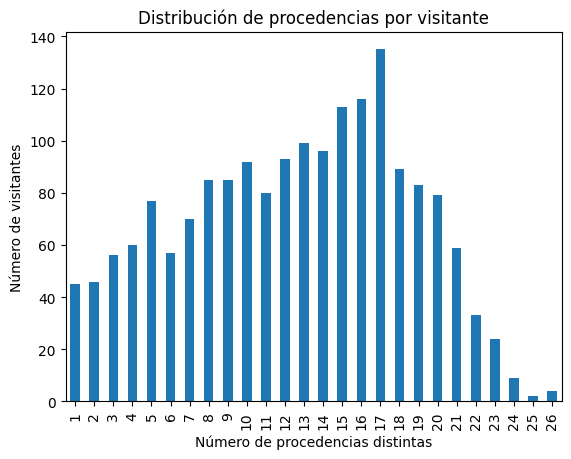

In [152]:
df_completo.groupby("id_visitante")["procedencia"] \
    .nunique() \
    .value_counts() \
    .sort_index() \
    .plot(kind="bar")

plt.xlabel("Número de procedencias distintas")
plt.ylabel("Número de visitantes")
plt.title("Distribución de procedencias por visitante")
plt.show()

# ELABORACION DE EDA DEL DATAFRAME COMPLETO

In [175]:
# info
df_completo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35885 entries, 0 to 35914
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   t_id                      35885 non-null  object        
 1   emocion                   35534 non-null  object        
 2   tiempo_recogida           35885 non-null  int64         
 3   valoracion                35885 non-null  int64         
 4   tiempo_recogida_fecha     35885 non-null  datetime64[ns]
 5   procedencia               35885 non-null  object        
 6   id_visitante              35885 non-null  int64         
 7   atraccion                 34747 non-null  object        
 8   comienzo_atraccion        35789 non-null  Int64         
 9   tiempo_de_espera          35885 non-null  int64         
 10  comienzo_atraccion_fecha  35789 non-null  datetime64[ns]
 11  tipo_entrada              35885 non-null  object        
 12  coste                  

In [176]:
# nulos
df_completo.isnull().sum() # Valores nulos de cada columna

,0
t_id,0
emocion,351
tiempo_recogida,0
valoracion,0
tiempo_recogida_fecha,0
procedencia,0
id_visitante,0
atraccion,1138
comienzo_atraccion,96
tiempo_de_espera,0


In [177]:
#Duplicados
num_dupl = df_completo.duplicated().sum()
num_dupl

np.int64(0)

In [178]:
#tipo de datos
df_completo.dtypes

,0
t_id,object
emocion,object
tiempo_recogida,int64
valoracion,int64
tiempo_recogida_fecha,datetime64[ns]
procedencia,object
id_visitante,int64
atraccion,object
comienzo_atraccion,Int64
tiempo_de_espera,int64


In [179]:
# Describe de todos los datos
df_completo.describe()

,tiempo_recogida,valoracion,tiempo_recogida_fecha,id_visitante,comienzo_atraccion,tiempo_de_espera,comienzo_atraccion_fecha,coste,antelacion_de_compra,duracion
count,35885.000000,35885.000000,35885,35885.000000,35789.0,35885.000000,35789,35885.000000,35885.000000,35885.000000
mean,359.592197,4.983921,2025-09-16 06:35:31.910268672,625.678027,358.421163,12.498203,2025-09-16 05:25:16.186537728,16.982474,118.797715,359.750397
min,2.000000,0.000000,2025-09-01 09:00:00,1.000000,-1.0,-3.000000,2025-09-01 06:00:00,-2.255834,0.000000,-39.000000
25%,181.000000,2.000000,2025-09-08 20:00:00,260.000000,179.0,10.000000,2025-09-08 18:00:00,13.605488,0.000000,292.000000
50%,359.000000,5.000000,2025-09-16 06:00:00,553.000000,357.0,12.000000,2025-09-16 04:00:00,17.003741,85.000000,359.000000
75%,539.000000,8.000000,2025-09-23 18:00:00,937.000000,538.0,15.000000,2025-09-23 17:00:00,20.338313,225.000000,428.000000
max,719.000000,10.000000,2025-10-01 06:00:00,1787.000000,719.0,28.000000,2025-10-01 06:00:00,39.326885,364.000000,811.000000
std,207.274279,3.153761,NaN,433.730867,207.874559,4.014150,NaN,4.975403,121.386687,100.116737


In [180]:
# Separamos valores numericos y categoricos:
columnas_object = df_completo.select_dtypes(include=['object']).columns
columnas_numeric = df_completo.select_dtypes(include=np.number).columns

In [181]:
columnas_numeric

Index(['tiempo_recogida', 'valoracion', 'id_visitante', 'comienzo_atraccion',
       'tiempo_de_espera', 'coste', 'antelacion_de_compra', 'duracion'],
      dtype='object')

In [182]:
columnas_object

Index(['t_id', 'emocion', 'procedencia', 'atraccion', 'tipo_entrada'], dtype='object')

<Axes: xlabel='valoracion', ylabel='Count'>

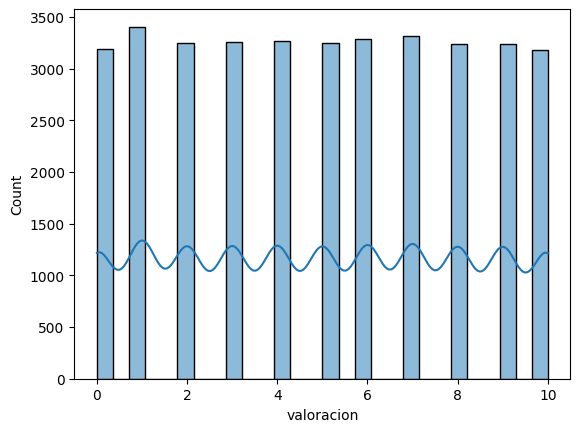

In [183]:
sns.histplot(df_completo["valoracion"], kde=True)

<Axes: xlabel='tiempo_de_espera', ylabel='Count'>

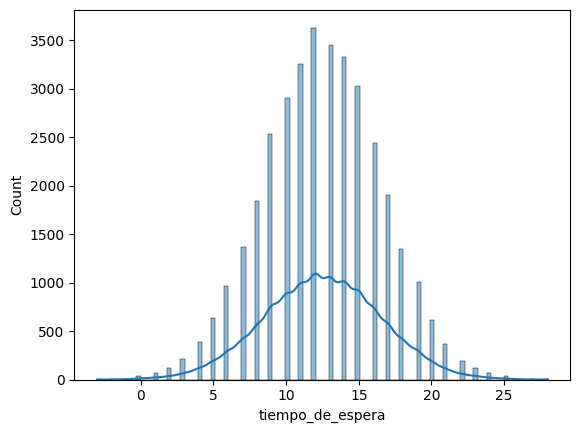

In [184]:
sns.histplot(df_completo["tiempo_de_espera"], kde=True)

<Axes: xlabel='coste', ylabel='Count'>

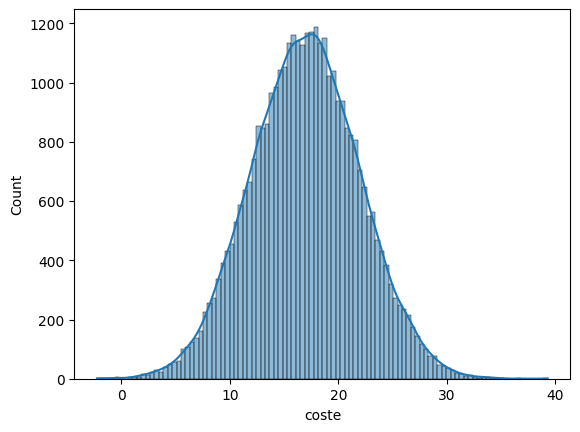

In [185]:
sns.histplot(df_completo["coste"], kde=True)

<Axes: xlabel='antelacion_de_compra', ylabel='Count'>

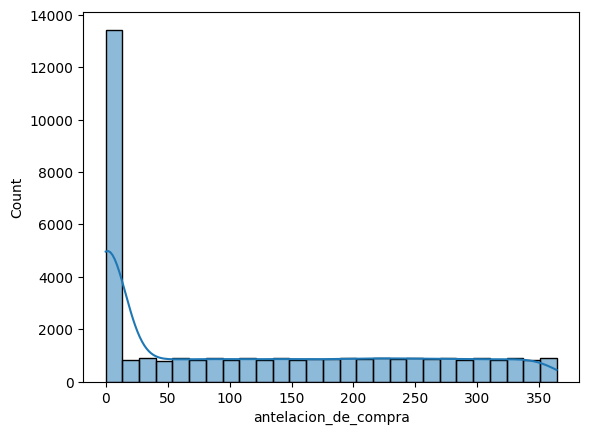

In [186]:
sns.histplot(df_completo["antelacion_de_compra"], kde=True)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34],
 [Text(0, 0, 'Montana Rusa de la Luna'),
  Text(1, 0, 'Carrusel Encantado'),
  Text(2, 0, 'Cine 4D Emocionante'),
  Text(3, 0, 'Fiesta de los Dulces'),
  Text(4, 0, 'Tobogan del Arco Iris'),
  Text(5, 0, 'Laberinto de Suenos'),
  Text(6, 0, 'Rueda de la Fortuna'),
  Text(7, 0, 'Torbellino Espacial'),
  Text(8, 0, 'Tren del Terror'),
  Text(9, 0, 'Mansion Embrujada'),
  Text(10, 0, 'Carrera de Autos Locos'),
  Text(11, 0, 'Vuelo Magico'),
  Text(12, 0, 'Jardin de las Hadas'),
  Text(13, 0, 'Arana Saltarina'),
  Text(14, 0, 'Selva Encantada'),
  Text(15, 0, 'Espejos de la Risuena'),
  Text(16, 0, 'Aventuras Acuaticas'),
  Text(17, 0, 'Dragon Volador'),
  Text(18, 0, 'Rapido del Trueno'),
  Text(19, 0, 'Mundo de las Maravillas'),
  Text(20, 0, 'Tirolina Extrema'),
  Text(21, 0, 'Gran Caida L

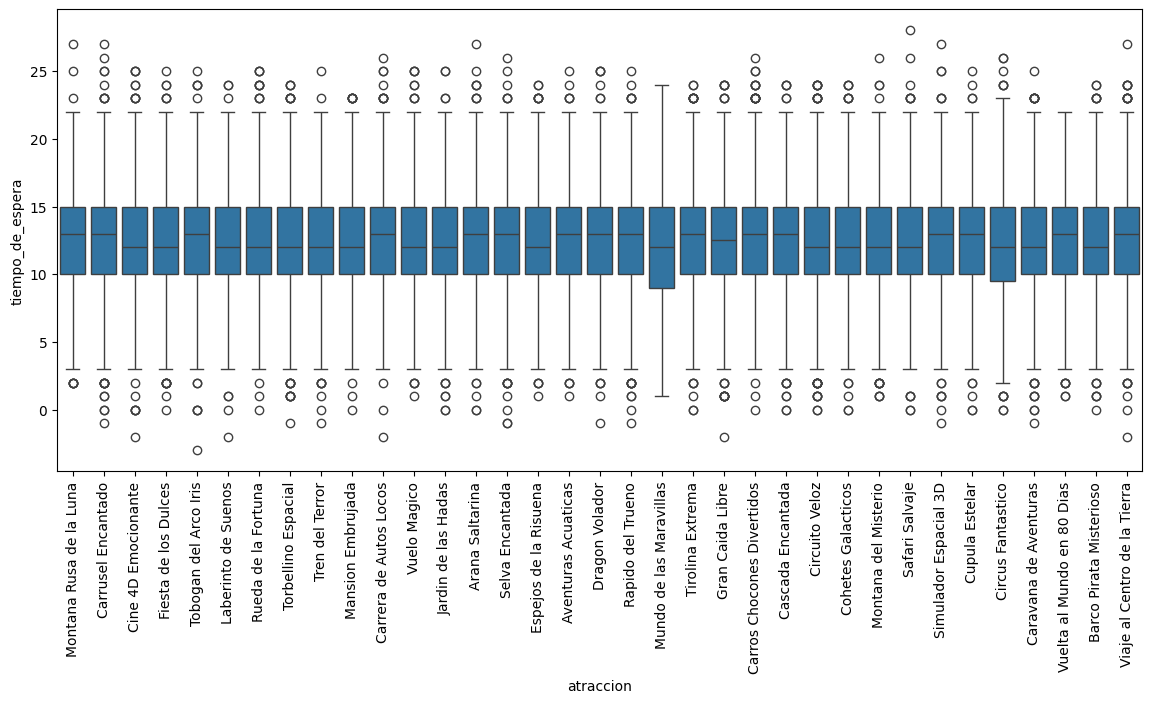

In [187]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df_completo, x="atraccion", y="tiempo_de_espera")
plt.xticks(rotation=90)

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Pase Anual'),
  Text(1, 0, 'Entrada Individual'),
  Text(2, 0, 'Entrada Infantil'),
  Text(3, 0, 'Entrada Familiar'),
  Text(4, 0, 'Paquete VIP'),
  Text(5, 0, 'Pase Rapido')])

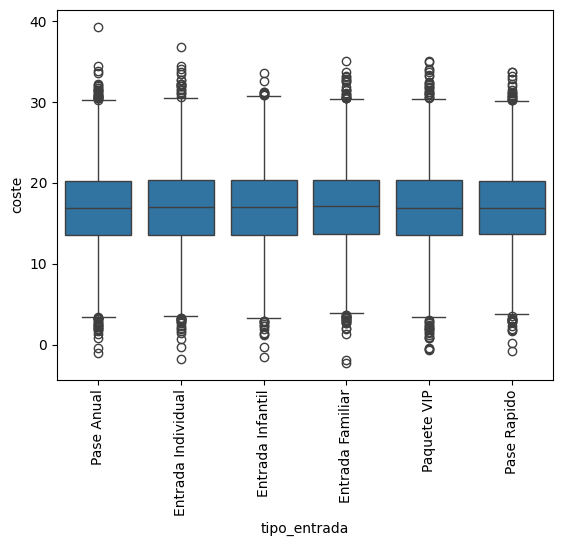

In [188]:
sns.boxplot(data=df_completo, x="tipo_entrada", y="coste")
plt.xticks(rotation=90)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34],
 [Text(0, 0, 'Montana Rusa de la Luna'),
  Text(1, 0, 'Carrusel Encantado'),
  Text(2, 0, 'Cine 4D Emocionante'),
  Text(3, 0, 'Fiesta de los Dulces'),
  Text(4, 0, 'Tobogan del Arco Iris'),
  Text(5, 0, 'Laberinto de Suenos'),
  Text(6, 0, 'Rueda de la Fortuna'),
  Text(7, 0, 'Torbellino Espacial'),
  Text(8, 0, 'Tren del Terror'),
  Text(9, 0, 'Mansion Embrujada'),
  Text(10, 0, 'Carrera de Autos Locos'),
  Text(11, 0, 'Vuelo Magico'),
  Text(12, 0, 'Jardin de las Hadas'),
  Text(13, 0, 'Arana Saltarina'),
  Text(14, 0, 'Selva Encantada'),
  Text(15, 0, 'Espejos de la Risuena'),
  Text(16, 0, 'Aventuras Acuaticas'),
  Text(17, 0, 'Dragon Volador'),
  Text(18, 0, 'Rapido del Trueno'),
  Text(19, 0, 'Mundo de las Maravillas'),
  Text(20, 0, 'Tirolina Extrema'),
  Text(21, 0, 'Gran Caida L

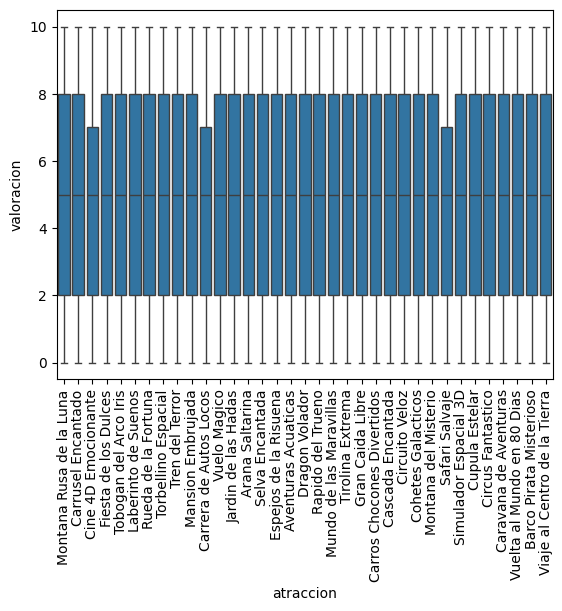

In [189]:
sns.boxplot(data=df_completo, x="atraccion", y="valoracion")
plt.xticks(rotation=90)

Es un gráfico de caja (boxplot), muestra las valoraciones (notas del 0 al 10) que recibe cada atracción.

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Pase Anual'),
  Text(1, 0, 'Entrada Individual'),
  Text(2, 0, 'Entrada Infantil'),
  Text(3, 0, 'Entrada Familiar'),
  Text(4, 0, 'Paquete VIP'),
  Text(5, 0, 'Pase Rapido')])

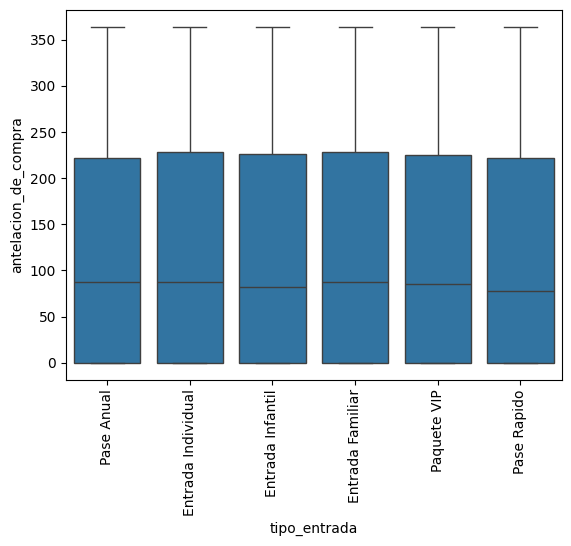

In [190]:
sns.boxplot(data=df_completo, x="tipo_entrada", y="antelacion_de_compra")
plt.xticks(rotation=90)

Es un gráfico de caja (boxplot).

Muestra cómo se distribuyen los días de antelación de compra según el tipo de entrada.

La línea del medio de cada caja: Es la mitad exacta de los datos (la mediana).

La caja azul: Concentra el 50% de las compras comunes.

Las "antenas" (líneas finas): Indican el mínimo y el máximo de días de antelación.

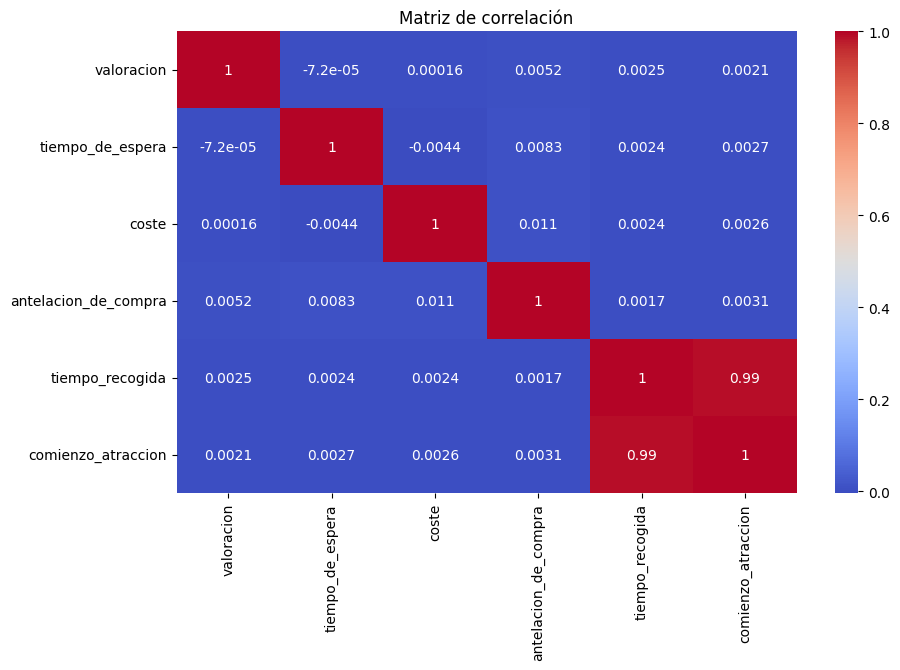

In [191]:
corr_cols = [
    "valoracion",
    "tiempo_de_espera",
    "coste",
    "antelacion_de_compra",
    "tiempo_recogida",
    "comienzo_atraccion"]

corr = df_completo[corr_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

Es una matriz de correlación (en formato mapa de calor).

Muestra qué tan relacionadas están las variables numéricas entre sí:

Los números (de -1 a 1): Cuanto más cerca estén del 1, mayor es la relación positiva (si una sube, la otra también). Si están cerca de 0, no tienen ninguna relación.

Los colores: El rojo indica una relación fuerte y el azul una nula o débil.

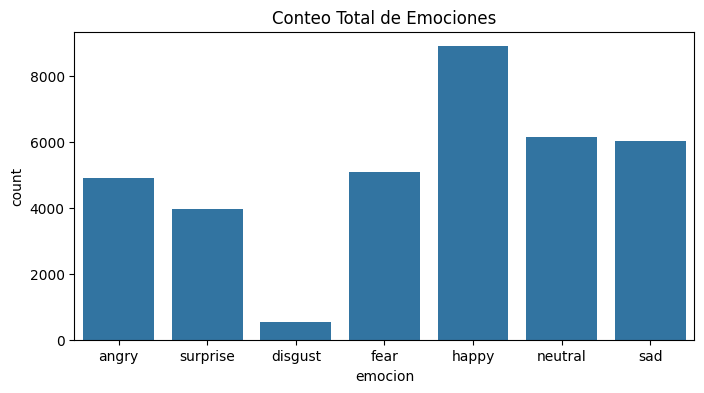

In [192]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df_completo, x='emocion')
plt.title('Conteo Total de Emociones')
plt.show()

Es un gráfico de barras que muestra la cantidad total de datos que tienes por cada emoción.
Te permite ver de un vistazo qué emociones se repiten más (como happy) y cuáles menos (como disgust).

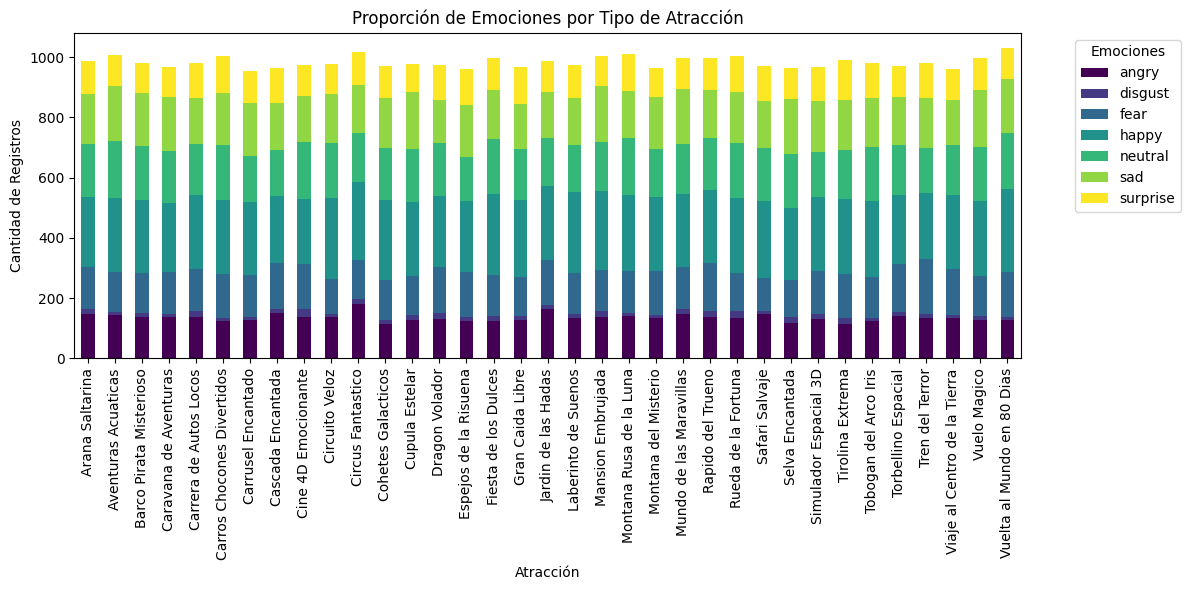

In [193]:
plt.figure(figsize=(12, 6))
tabla_emociones = pd.crosstab(df_completo['atraccion'], df_completo['emocion'])

tabla_emociones.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='viridis')

plt.title('Proporción de Emociones por Tipo de Atracción')
plt.xlabel('Atracción')
plt.ylabel('Cantidad de Registros')
plt.legend(title='Emociones', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Es un gráfico de barras apiladas.
Muestra cómo se dividen las emociones dentro de cada atracción de feria.
Cada barra es una atracción y los colores representan la cantidad de cada emoción en ella. Te permite comparar qué sentimientos predomina en cada sitio.


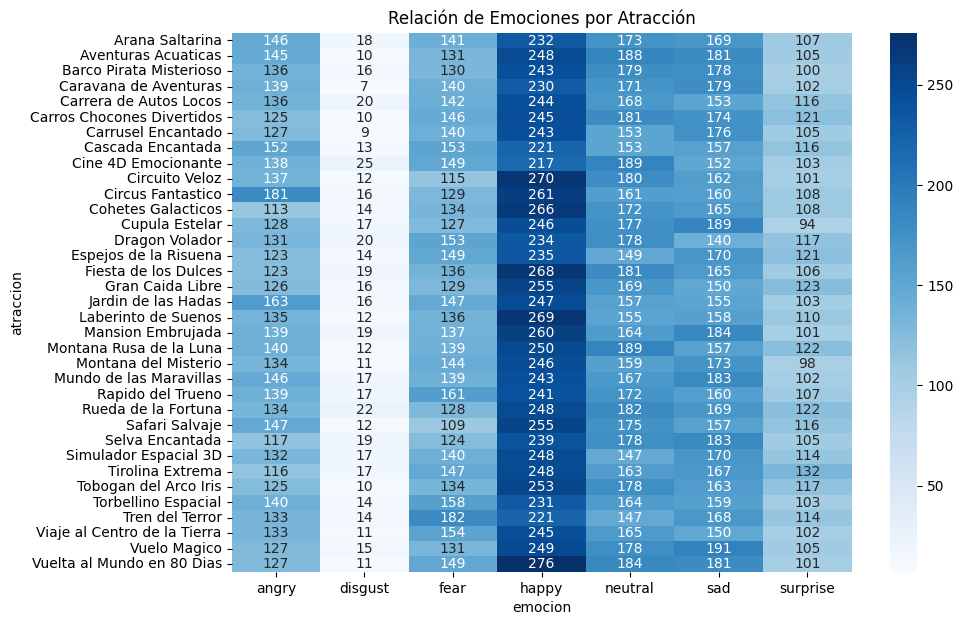

In [194]:
plt.figure(figsize=(10, 7))
tabla_emociones = pd.crosstab(df_completo['atraccion'], df_completo['emocion'])
sns.heatmap(tabla_emociones, annot=True, fmt="d", cmap='Blues')
plt.title('Relación de Emociones por Atracción')
plt.show()

Es un mapa de calor (heatmap).
Muestra la cantidad exacta de registros cruzando cada atracción con cada emoción mediante números y colores.
El tono del azul te da la respuesta al golpe de vista: el azul oscuro indica números altos (mucha coincidencia) y el azul claro o blanco indica números bajos.


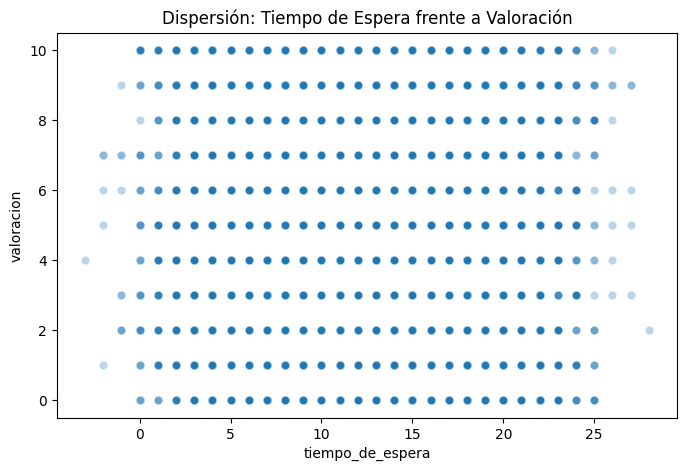

In [195]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_completo, x='tiempo_de_espera', y='valoracion', alpha=0.3)
plt.title('Dispersión: Tiempo de Espera frente a Valoración')
plt.show()

Es un gráfico de dispersión (scatterplot).
Muestra la relación entre dos cosas: el tiempo de espera (eje de abajo) y la valoración (eje izquierdo).
Cada punto es un registro. Al estar distribuidos de forma tan uniforme y cuadriculada, te indica que no hay una relación clara entre el tiempo que espera la gente y la nota que pone; hay puntuaciones altas y bajas en casi cualquier tiempo de espera.


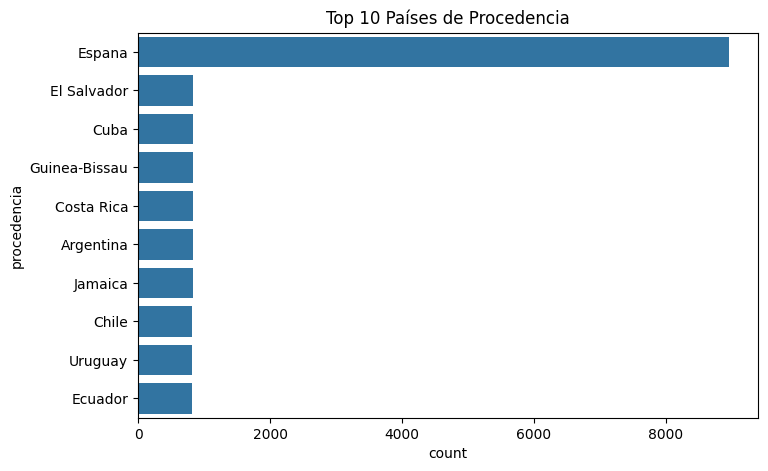

In [196]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_completo, y='procedencia', order=df_completo['procedencia'].value_counts().index[:10])
plt.title('Top 10 Países de Procedencia')
plt.show()

#CREAMOS LOS DATAFRAME IGUAL A LA BBDD

DATAFRAME fotografias

Las columnas de la tabla fotografias son:


*   t_id
*   id_emocion        --- id
*   valoracion
*   tiempo_recogida
*   tiempo_recogida_date








In [197]:
df_completo.columns

Index(['t_id', 'emocion', 'tiempo_recogida', 'valoracion',
       'tiempo_recogida_fecha', 'procedencia', 'id_visitante', 'atraccion',
       'comienzo_atraccion', 'tiempo_de_espera', 'comienzo_atraccion_fecha',
       'tipo_entrada', 'coste', 'antelacion_de_compra', 'duracion'],
      dtype='object')

In [198]:
df_fotografias = df_completo[["t_id", "emocion", "valoracion", "tiempo_recogida", "tiempo_recogida_fecha"]]
df_fotografias.head()

,t_id,emocion,valoracion,tiempo_recogida,tiempo_recogida_fecha
0,Training_10118481.jpg,angry,2,291,2025-09-13 10:00:00
1,Training_10120469.jpg,angry,6,425,2025-09-19 00:00:00
2,Training_10131352.jpg,angry,0,499,2025-09-22 02:00:00
3,Training_10161559.jpg,angry,4,715,2025-10-01 02:00:00
4,Training_1021836.jpg,angry,6,301,2025-09-13 20:00:00


Ahora tenemos que cambiar la columna de emocione por su id_emocion

In [199]:
df_fotografias_bbdd = df_fotografias.merge(df_emociones_bbdd, on="emocion", how="left")
df_fotografias_bbdd["id_emocion"] = (df_fotografias_bbdd["id_emocion"].fillna(100).astype("int64")) # Cambiamos null por un 100 y cambiamos tipo de dato de float a int
df_fotografias_bbdd

,t_id,emocion,valoracion,tiempo_recogida,tiempo_recogida_fecha,id_emocion
0,Training_10118481.jpg,angry,2,291,2025-09-13 10:00:00,0
1,Training_10120469.jpg,angry,6,425,2025-09-19 00:00:00,0
2,Training_10131352.jpg,angry,0,499,2025-09-22 02:00:00,0
3,Training_10161559.jpg,angry,4,715,2025-10-01 02:00:00,0
4,Training_1021836.jpg,angry,6,301,2025-09-13 20:00:00,0
...,...,...,...,...,...,...
35880,PublicTest_98089595.jpg,surprise,2,469,2025-09-20 20:00:00,1
35881,PublicTest_98567249.jpg,surprise,7,299,2025-09-13 18:00:00,1
35882,PublicTest_98972870.jpg,surprise,10,255,2025-09-11 22:00:00,1
35883,PublicTest_99242645.jpg,surprise,5,573,2025-09-25 04:00:00,1


In [200]:
df_fotografias_bbdd = df_fotografias_bbdd.drop(columns=["emocion"])
df_fotografias_bbdd

,t_id,valoracion,tiempo_recogida,tiempo_recogida_fecha,id_emocion
0,Training_10118481.jpg,2,291,2025-09-13 10:00:00,0
1,Training_10120469.jpg,6,425,2025-09-19 00:00:00,0
2,Training_10131352.jpg,0,499,2025-09-22 02:00:00,0
3,Training_10161559.jpg,4,715,2025-10-01 02:00:00,0
4,Training_1021836.jpg,6,301,2025-09-13 20:00:00,0
...,...,...,...,...,...
35880,PublicTest_98089595.jpg,2,469,2025-09-20 20:00:00,1
35881,PublicTest_98567249.jpg,7,299,2025-09-13 18:00:00,1
35882,PublicTest_98972870.jpg,10,255,2025-09-11 22:00:00,1
35883,PublicTest_99242645.jpg,5,573,2025-09-25 04:00:00,1


In [201]:
# Analizamos cuantos nulos tenemos
df_fotografias_bbdd["id_emocion"].isna().sum()

np.int64(0)

DATAFRAME registro_atracciones

Las columnas de la tabla registro_atracciones son:


*   t_id
*   id_atraccion   --- id
*   comienzo_atraccion
*   comienzo_atraccion_date
*   tiempo_espera

In [202]:
df_completo.columns

Index(['t_id', 'emocion', 'tiempo_recogida', 'valoracion',
       'tiempo_recogida_fecha', 'procedencia', 'id_visitante', 'atraccion',
       'comienzo_atraccion', 'tiempo_de_espera', 'comienzo_atraccion_fecha',
       'tipo_entrada', 'coste', 'antelacion_de_compra', 'duracion'],
      dtype='object')

In [203]:
df_registro_atracciones = df_completo[["t_id","atraccion","comienzo_atraccion","comienzo_atraccion_fecha","tiempo_de_espera"]]
df_registro_atracciones.head()

,t_id,atraccion,comienzo_atraccion,comienzo_atraccion_fecha,tiempo_de_espera
0,Training_10118481.jpg,Montana Rusa de la Luna,291,2025-09-13 10:00:00,5
1,Training_10120469.jpg,Carrusel Encantado,425,2025-09-19 00:00:00,11
2,Training_10131352.jpg,Cine 4D Emocionante,499,2025-09-22 02:00:00,13
3,Training_10161559.jpg,Fiesta de los Dulces,715,2025-10-01 02:00:00,12
4,Training_1021836.jpg,Tobogan del Arco Iris,301,2025-09-13 20:00:00,17


Ahora tenemos que cambiar la columna de atraccion por su id_atraccion

In [204]:
df_registro_atracciones_bbdd = df_registro_atracciones.merge(df_atracciones_bbdd, on="atraccion", how="left")
df_registro_atracciones_bbdd["id_atraccion"] = (df_registro_atracciones_bbdd["id_atraccion"].fillna(100).astype("int64")) # Cambiamos null por un 100 y cambiamos tipo de dato de float a int
df_registro_atracciones_bbdd

,t_id,atraccion,comienzo_atraccion,comienzo_atraccion_fecha,tiempo_de_espera,id_atraccion
0,Training_10118481.jpg,Montana Rusa de la Luna,291,2025-09-13 10:00:00,5,0
1,Training_10120469.jpg,Carrusel Encantado,425,2025-09-19 00:00:00,11,20
2,Training_10131352.jpg,Cine 4D Emocionante,499,2025-09-22 02:00:00,13,5
3,Training_10161559.jpg,Fiesta de los Dulces,715,2025-10-01 02:00:00,12,3
4,Training_1021836.jpg,Tobogan del Arco Iris,301,2025-09-13 20:00:00,17,6
...,...,...,...,...,...,...
35880,PublicTest_98089595.jpg,Carrera de Autos Locos,469,2025-09-20 20:00:00,16,24
35881,PublicTest_98567249.jpg,Circuito Veloz,299,2025-09-13 18:00:00,14,28
35882,PublicTest_98972870.jpg,Cine 4D Emocionante,255,2025-09-11 22:00:00,9,5
35883,PublicTest_99242645.jpg,Simulador Espacial 3D,573,2025-09-25 04:00:00,10,2


In [205]:
df_registro_atracciones_bbdd = df_registro_atracciones_bbdd.drop(columns=["atraccion"])
df_registro_atracciones_bbdd

,t_id,comienzo_atraccion,comienzo_atraccion_fecha,tiempo_de_espera,id_atraccion
0,Training_10118481.jpg,291,2025-09-13 10:00:00,5,0
1,Training_10120469.jpg,425,2025-09-19 00:00:00,11,20
2,Training_10131352.jpg,499,2025-09-22 02:00:00,13,5
3,Training_10161559.jpg,715,2025-10-01 02:00:00,12,3
4,Training_1021836.jpg,301,2025-09-13 20:00:00,17,6
...,...,...,...,...,...
35880,PublicTest_98089595.jpg,469,2025-09-20 20:00:00,16,24
35881,PublicTest_98567249.jpg,299,2025-09-13 18:00:00,14,28
35882,PublicTest_98972870.jpg,255,2025-09-11 22:00:00,9,5
35883,PublicTest_99242645.jpg,573,2025-09-25 04:00:00,10,2


In [206]:
# Analizamos cuantos nulos tenemos
df_registro_atracciones_bbdd["id_atraccion"].isna().sum()

np.int64(0)

DATAFRAME registro_tiquets

Las columnas de la tabla registro_tickets son:


*   t_id
*   id_tipo_entrada  --- id
*   coste
*   antelacion

In [207]:
df_completo.columns

Index(['t_id', 'emocion', 'tiempo_recogida', 'valoracion',
       'tiempo_recogida_fecha', 'procedencia', 'id_visitante', 'atraccion',
       'comienzo_atraccion', 'tiempo_de_espera', 'comienzo_atraccion_fecha',
       'tipo_entrada', 'coste', 'antelacion_de_compra', 'duracion'],
      dtype='object')

In [208]:
df_registro_tiquets = df_completo[["t_id","tipo_entrada","coste","antelacion_de_compra"]]
df_registro_tiquets.rename(columns={"antelacion_de_compra":"antelacion"}, inplace=True)
df_registro_tiquets.head()

,t_id,tipo_entrada,coste,antelacion
0,Training_10118481.jpg,Pase Anual,14.003708,0
1,Training_10120469.jpg,Entrada Individual,13.794903,113
2,Training_10131352.jpg,Entrada Infantil,19.059902,25
3,Training_10161559.jpg,Entrada Individual,17.722234,320
4,Training_1021836.jpg,Entrada Individual,20.501200,271


Ahora tenemos que cambiar la columna de tipo_entrada por su id_tipo_entrada

In [209]:
df_registro_tiquets_bbdd = df_registro_tiquets.merge(df_tipos_entrada_bbdd, on="tipo_entrada", how="left")
df_registro_tiquets_bbdd

,t_id,tipo_entrada,coste,antelacion,id_tipo_entrada
0,Training_10118481.jpg,Pase Anual,14.003708,0,0
1,Training_10120469.jpg,Entrada Individual,13.794903,113,5
2,Training_10131352.jpg,Entrada Infantil,19.059902,25,2
3,Training_10161559.jpg,Entrada Individual,17.722234,320,5
4,Training_1021836.jpg,Entrada Individual,20.501200,271,5
...,...,...,...,...,...
35880,PublicTest_98089595.jpg,Pase Anual,14.009224,144,0
35881,PublicTest_98567249.jpg,Entrada Infantil,18.311134,39,2
35882,PublicTest_98972870.jpg,Pase Anual,21.505071,276,0
35883,PublicTest_99242645.jpg,Entrada Familiar,11.229551,168,1


In [210]:
df_registro_tiquets_bbdd = df_registro_tiquets_bbdd.drop(columns=["tipo_entrada"])
df_registro_tiquets_bbdd

,t_id,coste,antelacion,id_tipo_entrada
0,Training_10118481.jpg,14.003708,0,0
1,Training_10120469.jpg,13.794903,113,5
2,Training_10131352.jpg,19.059902,25,2
3,Training_10161559.jpg,17.722234,320,5
4,Training_1021836.jpg,20.501200,271,5
...,...,...,...,...
35880,PublicTest_98089595.jpg,14.009224,144,0
35881,PublicTest_98567249.jpg,18.311134,39,2
35882,PublicTest_98972870.jpg,21.505071,276,0
35883,PublicTest_99242645.jpg,11.229551,168,1


In [211]:
# Analizamos cuantos nulos tenemos
df_registro_tiquets_bbdd["id_tipo_entrada"].isna().sum()

np.int64(0)

DATAFRAME info_visitantes

Las columnas de la tabla info_visitantes son:


*   t_id
*   id_visitante
*   id_procedencia  --- id
*   duracion

In [212]:
df_completo.columns

Index(['t_id', 'emocion', 'tiempo_recogida', 'valoracion',
       'tiempo_recogida_fecha', 'procedencia', 'id_visitante', 'atraccion',
       'comienzo_atraccion', 'tiempo_de_espera', 'comienzo_atraccion_fecha',
       'tipo_entrada', 'coste', 'antelacion_de_compra', 'duracion'],
      dtype='object')

In [213]:
df_info_visitantes = df_completo[["t_id","id_visitante","procedencia","duracion"]]
df_info_visitantes.head()

,t_id,id_visitante,procedencia,duracion
0,Training_10118481.jpg,3,Filipinas,308
1,Training_10120469.jpg,4,India,103
2,Training_10131352.jpg,5,Espana,371
3,Training_10161559.jpg,6,Espana,228
4,Training_1021836.jpg,7,Canada,247


Ahora tenemos que cambiar la columna de procedencia por su id_procedencia

In [214]:
df_info_visitantes_bbdd = df_info_visitantes.merge(df_procedencias_bbdd, on="procedencia", how="left")
df_info_visitantes_bbdd

,t_id,id_visitante,procedencia,duracion,id_procedencia
0,Training_10118481.jpg,3,Filipinas,308,0
1,Training_10120469.jpg,4,India,103,16
2,Training_10131352.jpg,5,Espana,371,1
3,Training_10161559.jpg,6,Espana,228,1
4,Training_1021836.jpg,7,Canada,247,11
...,...,...,...,...,...
35880,PublicTest_98089595.jpg,189,Espana,361,1
35881,PublicTest_98567249.jpg,833,Espana,308,1
35882,PublicTest_98972870.jpg,553,Francia,407,28
35883,PublicTest_99242645.jpg,1009,El Salvador,532,14


In [215]:
df_info_visitantes_bbdd  = df_info_visitantes_bbdd.drop(columns=["procedencia"])
df_info_visitantes_bbdd

,t_id,id_visitante,duracion,id_procedencia
0,Training_10118481.jpg,3,308,0
1,Training_10120469.jpg,4,103,16
2,Training_10131352.jpg,5,371,1
3,Training_10161559.jpg,6,228,1
4,Training_1021836.jpg,7,247,11
...,...,...,...,...
35880,PublicTest_98089595.jpg,189,361,1
35881,PublicTest_98567249.jpg,833,308,1
35882,PublicTest_98972870.jpg,553,407,28
35883,PublicTest_99242645.jpg,1009,532,14


In [216]:
# Analizamos cuantos nulos tenemos
df_info_visitantes_bbdd["id_procedencia"].isna().sum()

np.int64(0)

# CONEXION CON LA BASE DE DATOS JSM  ¡no ejecutar!

In [ ]:
# librerias
import pandas as pd
from sqlalchemy import create_engine, inspect
from sqlalchemy.exc import SQLAlchemyError

In [ ]:
# Subir un DataFrame a MySQL automáticamente
# - Detecta si la tabla existe
# - La crea si no existe
# - Inserta datos si ya existe

# FUNCIÓN PRINCIPAL
def subir_dataframe(df, nombre_tabla, engine):
    """
    Inserta un DataFrame en MySQL:
      - Si la tabla no existe, la crea automáticamente.
      - Si la tabla existe, agrega los datos sin tocarla.
    """
    try:
        inspector = inspect(engine)
        tablas_existentes = inspector.get_table_names()

        if nombre_tabla not in tablas_existentes:
            print(f"La tabla '{nombre_tabla}' no existe. Se creará automáticamente...")
            df.to_sql(name=nombre_tabla, con=engine, if_exists="replace", index=False)
            print(f"Tabla '{nombre_tabla}' creada y datos insertados.")
        else:
            print(f"La tabla '{nombre_tabla}' ya existe. Se agregarán los datos...")
            df.to_sql(name=nombre_tabla, con=engine, if_exists="append", index=False, method="multi")
            print(f"Datos agregados correctamente en la tabla '{nombre_tabla}'.")

    except SQLAlchemyError as e:
        print("Error al insertar datos:", str(e))

In [ ]:
# CONFIGURACIÓN DE CONEXIÓN
usuario = "root"  # revisar y cambiar
contrasena = "root"   # cambiar esto
host = "127.0.0.1" # revisar y cambiar
puerto = "3306"
base_datos = "reconocimiento_emociones"   # usar base de datos real

In [ ]:
# Crear el engine de conexión
engine = create_engine(f"mysql+mysqlconnector://{usuario}:{contrasena}@{host}:{puerto}/{base_datos}")

In [ ]:
# LLAMADAS A LA FUNCIÓN. subomos los DT de variables categoricas a las tablas de la BBDD. (Desde Visual Studio Code)
# LAs librerias hay que instalarlas en la terminal de VSC, no vale con poner esto: !pip install mysql-connector-python !pip install SQLAlchemy
# He puesto esto en la terminal: pip install pandas    pip install sqlalchemy  pip install mysql-connector-python
subir_dataframe(df_emociones_bbdd, "emociones", engine)
subir_dataframe(df_procedencias_bbdd, "procedencias", engine)
subir_dataframe(df_atracciones_bbdd, "atracciones", engine)
subir_dataframe(df_tipos_entrada_bbdd, "tipos_entrada", engine)

In [ ]:
subir_dataframe(df_fotografias_bbdd, "fotografias", engine)

In [ ]:
subir_dataframe(df_registro_atracciones_bbdd, "registro_atracciones", engine)

In [ ]:
subir_dataframe(df_registro_tiquets_bbdd, "registro_tiquets", engine)

In [ ]:
subir_dataframe(df_info_visitantes_bbdd, "info_visitantes", engine)

# ------LIMPIEZA DE DATOS

--1: • **Completitud del dato**: Identificar valores faltantes (NaN, null, blancos, …), analizarlos, y proponer una estrategia de limpieza de estos datos: rellenarlos, eliminar ciertos registros o dejarlos como se facilitan inicialmente. Esta estrategia debe estar justificada con las observaciones vistas en el EDA (análisis exploratorio de datos) que debe llevarse a cabo.  

Vamos a analizar a detalle los nulos que tenemos. Creo que se pueden eliminar todos menos los 1138 de atracciones. Hay que ver que hacemos con ellos.

2: **Duplicidad**:  revisar si existen registros repetidos que podrían distorsionar el análisis, analizarlos y proponer una estrategia de limpieza de estos datos. Esta estrategia debe estar justificada con las observaciones vistas en el EDA que debe llevarse a cabo. Guion de Proyecto Júpiter 6

Tenemos fos fotos duplicadas y tras analizarlo, no encontramos un posible patron, asi que hemos decidido eliminarlas

3: • **Consistencia de formatos**: revisar la existencia de inconsistencias de formato en los datos (columnas con tipos de datos diferentes, fechas en distintos formatos, unificación de valores iguales escritos diferentes, …), analizarlos y aplicar una estrategia de limpieza de datos. Esta estrategia debe estar justificada con las observaciones vistas en el EDA que debe llevarse a cabo.

Los minutos ya se han pasado a fechas, tambien hemos limpiado la codificacion de las tildes y las Ñ.  Los ID_visitantes eran string y los hemos pasado a int

--4: • **Rangos y valores atípicos**: identificación de existencia de rangos de valores erróneos. Deben distinguirse aquellos valores que sean erróneos (como una edad negativa) de valores extremos válidos pero infrecuentes (outliers legítimos). Tras su identificación deben analizarse y proponer una estrategia de limpieza de estos datos. Esta estrategia debe estar justificada con las observaciones vistas en el EDA que debe llevarse a cabo.

Tenemos minutos negativos. Los podemos eliminar porque son muy pocos registros o sumar cantidada fija….

5: • **Homogeneidad de unidades y escalas**:identificar si existen medidas en diferentes unidades o escalas, analizarlas y proponer una estrategia de limpieza de estos datos. Esta estrategia debe estar justificada con las observaciones vistas en el EDA que debe llevarse a cabo

Todos los datos de nuestro data  frame tienen unas unidades y escalas correctas.

6: • **Relevancia de variables**: identificar campos redundantes o irrelevantes (columnas que no aportan al análisis y puedan eliminarse) y/o correlaciones fuertes.

Las columnas de tiempo de recogida y comienzo atraccion es exactamente la misma. con lo que una de las dos la podemos eliminar.

In [217]:
df_completo[["comienzo_atraccion", "tiempo_recogida"]].corr()


,comienzo_atraccion,tiempo_recogida
comienzo_atraccion,1.000000,0.990403
tiempo_recogida,0.990403,1.000000


7: • **Detección de sesgos**: evaluar si hay sobre-representación o infra-representación de algún grupo período o categoría y revisar si faltan registros que pudieran distorsionar las conclusiones.

En este apartado tenemos las procedencias de los visitantes, que como vemos la nacionalidad española es totalemtne mayoritaria. Pero no van a distorsionar nuestras conclusiones:

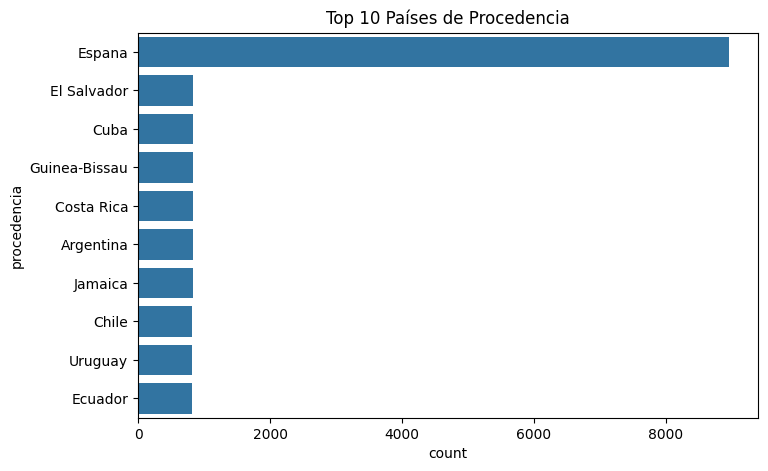

In [245]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_completo, y='procedencia', order=df_completo['procedencia'].value_counts().index[:10])
plt.title('Top 10 Países de Procedencia')
plt.show()

--8: • **Consistencia del dato**: verificar si existen contradicciones entre las diferentes variables, analizarlas y proponer una estrategia de limpieza de estos datos. Esta estrategia debe estar justificada con las observaciones vistas en el EDA que debe llevarse a cabo

Hay que ver las horas de recogida con normales con los horarios del parque. Es raro que por ejemplo tengamos mas a las 6 de la mañana que a las 12 (Visto en KPIs)

Claramente un Id de visitante no corresponde con el mismo visitante porque por ejemplo tiene varias nacionalidades distintas.

# DETECCION DE ERRORES

## La estancia de un visitante no puede superar las 9 horas.

In [309]:
# Creamos la columna de día
df_completo['dia'] = df_completo['comienzo_atraccion_fecha'].dt.date

# Agrupamos por día y visitante, tomando la duración de su estancia
estancia = df_completo.groupby(['dia', 'id_visitante'])['duracion'].max().reset_index()
estancia = estancia.rename(columns={'duracion': 'estancia_minutos'})

# Pasamos a horas para comparar con el límite de 9 horas
estancia['estancia_horas'] = estancia['estancia_minutos'] / 60

# Filtramos las que superan las 9 horas
errores_estancias = estancia[estancia['estancia_horas'] > 9]

print(f"Violaciones (más de 9 horas): {len(errores_estancias)}")

errores_estancias.sort_values('estancia_horas', ascending=False)

Violaciones (más de 9 horas): 1249


,dia,id_visitante,estancia_minutos,estancia_horas
10936,2025-09-14,903,811,13.516667
1289,2025-09-02,1000,746,12.433333
24082,2025-09-30,1141,744,12.400000
19328,2025-09-24,1434,738,12.300000
20012,2025-09-25,1076,728,12.133333
17529,2025-09-22,997,725,12.083333
14178,2025-09-18,892,716,11.933333
20810,2025-09-26,1033,712,11.866667
22067,2025-09-28,356,704,11.733333
4679,2025-09-06,1510,700,11.666667


Como vemos, hay 1249 regustros en los que un visitante ha estado mas de 9 horas al dia, pero los datos pueden darse como validos porque ninguno supera las 13 horas.

## Las entradas fast-pass se venden como máximo con 3 días de antelación.

In [299]:
# Filtramos solo las entradas Pase Rapido
fast_pass = df_completo[df_completo['tipo_entrada'] == 'Pase Rapido']
# Ahora buscamos si hay registros que se compran con mas de tres dias de antelacion
errores_fast_pass = fast_pass[fast_pass['antelacion_de_compra'] > 3]
print(f"Total de Pases Rápidos: {len(fast_pass)}")
print(f"registros erroneos de mas de 3 días de antelación: {len(errores_fast_pass)}\n")
#errores_fast_pass.sort_values('antelacion_de_compra', ascending=False).head(100)

Total de Pases Rápidos: 5986
registros erroneos de mas de 3 días de antelación: 3780



<Axes: xlabel='antelacion_de_compra', ylabel='Count'>

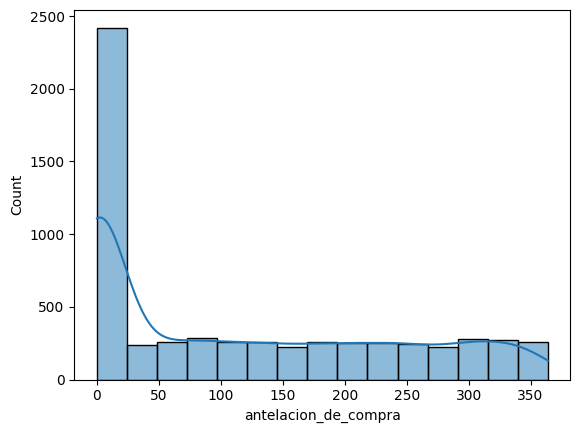

In [300]:
sns.histplot(fast_pass["antelacion_de_compra"], kde=True)

<Axes: xlabel='antelacion_de_compra', ylabel='Count'>

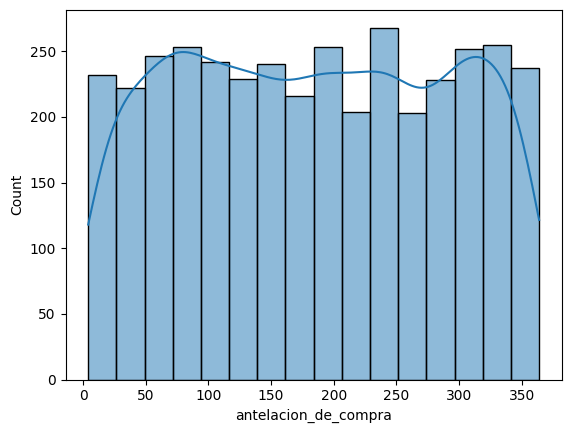

In [303]:
sns.histplot(errores_fast_pass["antelacion_de_compra"], kde=True)

En este caso, tenemos 5986 pases rapidos y 3780 tiene mas de 3 dias de antelacion y la distrubucion de estos valores erroneos esta muy distribuida de 0 a 350 dias, lo que nos hace pensar que en vez de dias puedan ser minutos.

## No hay ninguna atracción a la que se puedan subir más de 500 visitantes en una misma hora.

In [289]:
df_completo['hora'] = df_completo['comienzo_atraccion_fecha'].dt.floor('H')

# Agrupamos por atracción y hora, y hacemos u nrecuento de visitantes.
conteo = df_completo.groupby(['atraccion', 'hora'])['id_visitante'].count().reset_index()
conteo = conteo.rename(columns={'id_visitante': 'num_visitantes'})

conteo.sort_values('num_visitantes', ascending=False)


,atraccion,hora,num_visitantes
2577,Carrera de Autos Locos,2025-09-24 22:00:00,9
3379,Carrusel Encantado,2025-09-07 17:00:00,8
18177,Vuelo Magico,2025-09-20 23:00:00,8
11858,Montana del Misterio,2025-09-29 19:00:00,8
12108,Mundo de las Maravillas,2025-09-14 05:00:00,8
16709,Torbellino Espacial,2025-09-30 05:00:00,7
10249,Mansion Embrujada,2025-09-01 06:00:00,7
6536,Cupula Estelar,2025-09-04 04:00:00,7
12193,Mundo de las Maravillas,2025-09-18 21:00:00,7
11760,Montana del Misterio,2025-09-24 05:00:00,7


Como vemos, La atraccion que mas visitantes tiene en una hora es la de Autos locos con un total de 9 visitantes el dia 24 de septiembre a las 10 de la noche. Que repartida esta la gente no??

Vamos a coger una atraccion, un dia y vamos a ver en un grafico cuantos visitantes tiene por hora

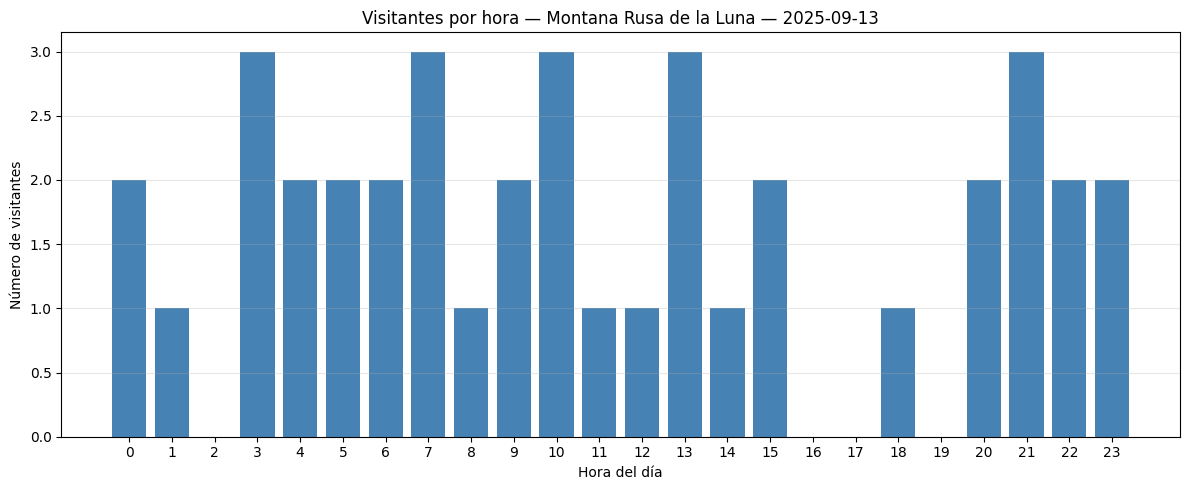

In [304]:


# --- Aqui ponemos la atraccion que queremos y el dia que queremos ---
atraccion_elegida = 'Montana Rusa de la Luna'
dia_elegido = '2025-09-13'
# ---------------------------------------------

# Filtramos por atracción y por día
filtro = (
    (df_completo['atraccion'] == atraccion_elegida) &
    (df_completo['comienzo_atraccion_fecha'].dt.date.astype(str) == dia_elegido)
)
df_dia = df_completo[filtro]

# Agrupamos por hora y contamos visitantes
visitantes_por_hora = df_dia.groupby(df_dia['comienzo_atraccion_fecha'].dt.hour)['id_visitante'].count()

# Reindexamos para que se vean las 24 horas aunque alguna tenga 0 visitantes
visitantes_por_hora = visitantes_por_hora.reindex(range(24), fill_value=0)

# Graficamos
plt.figure(figsize=(12, 5))
plt.bar(visitantes_por_hora.index, visitantes_por_hora.values, color='steelblue')
plt.xlabel('Hora del día')
plt.ylabel('Número de visitantes')
plt.title(f'Visitantes por hora — {atraccion_elegida} — {dia_elegido}')
plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

 ## La valoración es un valor comprendido entre 0 y 10.


In [ ]:
# Vamos a ver cuantos valores de valoraciones distintos tenemos y su descriptivo
df_valoraciones["valoracion"].describe()

,valoracion
count,35885.000000
mean,4.983921
std,3.153761
min,0.000000
25%,2.000000
50%,5.000000
75%,8.000000
max,10.000000


Como vemos, todas las valoraciones estan entre 0 a 10 correctamente

# ---- DATA SET PARA MACHINE LEARNING

La columna de tiempo recogida se puede eliminar ya que es igual a la de comienzo atraccion. Tanto la de fecha como la de entero. Luego hay que ver que hacemos con las fechas.....

La columna id tambien se puede eliminar. no aporta nada

Transformar la salida (Y = emocion) a un dato numerico de 1 a 6 y ver las correlaciones que tienen las demas variables. Aplicamos label encode.

Atraccion_ Hay que hacer un one hot encoding

Tipo de entrada_ Hay que analizar si vale la pena metersela al algoritmo. Si se la metenmos hay que hacer one hot encoding.

Luego podemos normalizar los datos....

Para la nacionalidad, propongo agruparlas en Española y en otras para hacer one hot encoding solamente de 2 categorias